# Predicción de Quiebra y Valoración Empresarial — Modelo Integrado

## Dataset: US Companies Bankruptcy Prediction (1999–2018)

**Sara Elizabeth Martinez Osorio**
**Asesora:** Paula María Almonacid Hurtado
**Maestría en Ciencias de los Datos y la Analítica — Universidad EAFIT — 2026**

---

1. **Sin fugas de información (data leakage):**
   - La winsorización y el cálculo de medianas/MAD se realizan **únicamente sobre el conjunto de entrenamiento**, y luego se aplican a validación y test.
   - El split de datos se realiza **por empresa** (estratificado por `ever_failed`), garantizando que ninguna empresa aparezca simultáneamente en train, val y test. La validación temporal se preserva mediante **Walk-Forward CV** sobre train+val.
   - La calibración isotónica se ajusta sobre el conjunto de **validación**, no sobre el de entrenamiento.

2. **Integración riesgo–valor individualizada por empresa:**
   - El valor DCF se calcula con los **fundamentales propios de cada empresa** (EBIT, D&A, ventas), no con valores aleatorios extraídos de una distribución general.
   - Cada empresa tiene su propio FCFF estimado mediante: $FCFF = EBIT \times (1 - t) + D\&A - CapEx_{aprox}$, donde $CapEx_{aprox} \approx D\&A$ (supuesto de steady-state).
   - El Monte Carlo varía únicamente los parámetros de descuento (WACC, g), preservando los fundamentales individuales.




---
## PARTE I: Setup y pipeline base


In [1]:
import subprocess, sys
pkgs = ['xgboost','lightgbm','imbalanced-learn','shap','optuna']
subprocess.check_call([sys.executable,'-m','pip','install','-q']+pkgs)
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Paquetes OK')


Paquetes OK


C:\Users\Hogar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
import time
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score,
    matthews_corrcoef, confusion_matrix, average_precision_score,
    precision_recall_curve, roc_curve)
from sklearn.preprocessing import RobustScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from imblearn.over_sampling import SMOTE
import xgboost as xgb, lightgbm as lgb
sns.set_style('whitegrid')
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
COSTO_FN, COSTO_FP = 100, 5   # 1 quiebra perdida = 20 falsas alarmas
print('Librerias OK')


Librerias OK


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# PIPELINE BASE — VERSIÓN SIN FUGAS DE INFORMACIÓN
# ═══════════════════════════════════════════════════════════════════════
# Cambios respecto a versiones previas:
#   1. Split POR EMPRESA estratificado por outcome (no por año):
#      garantiza que ninguna empresa aparezca en >1 conjunto.
#   2. La validación temporal se preserva mediante Walk-Forward CV
#      sobre train+val (TimeSeriesSplit más adelante).
#   3. Winsorización y escalado se ajustan SOLO en train y se aplican
#      a val/test (fit_on_train, transform_on_others).
# ═══════════════════════════════════════════════════════════════════════

# ── Carga del dataset real ───────────────────────────────────────────────
url = 'https://raw.githubusercontent.com/sowide/bankruptcy_dataset/main/american_bankruptcy_dataset.csv'
df  = pd.read_csv(url)
col_map = {'X1':'Current_assets','X2':'Cost_of_goods_sold','X3':'Depreciation_amort',
    'X4':'EBITDA','X5':'Inventory','X6':'Net_Income','X7':'Total_Receivables',
    'X8':'Market_value','X9':'Net_sales','X10':'Total_assets','X11':'Total_LT_debt',
    'X12':'EBIT','X13':'Gross_Profit','X14':'Total_Current_Liabilities',
    'X15':'Retained_Earnings','X16':'Total_Revenue','X17':'Total_Liabilities','X18':'Total_OpEx'}
df.rename(columns=col_map, inplace=True)
df.drop(columns=['Division','MajorGroup'], inplace=True, errors='ignore')
df = df.sort_values(['company_name','fyear']).reset_index(drop=True)
df['fyear'] = df['fyear'].astype(int)

# ── Feature engineering (sobre todo el dataset porque son cocientes
#    de variables propias de cada fila, no estadísticos agregados) ────────
df_fe = df.copy(); eps = 1e-8
df_fe['ROA']          = df_fe['Net_Income']       / (df_fe['Total_assets']              + eps)
df_fe['ROE']          = df_fe['Net_Income']       / (df_fe['Market_value']              + eps)
df_fe['Profit_Margin']= df_fe['Net_Income']       / (df_fe['Net_sales']                 + eps)
df_fe['Asset_Turn']   = df_fe['Net_sales']        / (df_fe['Total_assets']              + eps)
df_fe['Debt_Ratio']   = df_fe['Total_Liabilities']/ (df_fe['Total_assets']              + eps)
df_fe['Equity_Ratio'] = df_fe['Market_value']     / (df_fe['Total_assets']              + eps)
df_fe['Current_Ratio']= df_fe['Current_assets']   / (df_fe['Total_Current_Liabilities'] + eps)
df_fe['WC_TA']        = (df_fe['Current_assets']  - df_fe['Total_Current_Liabilities']) / (df_fe['Total_assets'] + eps)
df_fe['EBITDA_Margin']= df_fe['EBITDA']           / (df_fe['Net_sales']                 + eps)
df_fe['EBIT_TA']      = df_fe['EBIT']             / (df_fe['Total_assets']              + eps)
df_fe['RE_TA']        = df_fe['Retained_Earnings']/ (df_fe['Total_assets']              + eps)
df_fe['LTD_TA']       = df_fe['Total_LT_debt']    / (df_fe['Total_assets']              + eps)
df_fe['Gross_Margin'] = df_fe['Gross_Profit']     / (df_fe['Net_sales']                 + eps)
df_fe['OpEx_Rev']     = df_fe['Total_OpEx']       / (df_fe['Total_Revenue']             + eps)
df_fe['Recv_TA']      = df_fe['Total_Receivables']/ (df_fe['Total_assets']              + eps)
df_fe['Inv_TA']       = df_fe['Inventory']        / (df_fe['Total_assets']              + eps)
df_fe['MktVal_Liab']  = df_fe['Market_value']     / (df_fe['Total_Liabilities']         + eps)
df_fe['Altman_Z']     = (1.2*df_fe['WC_TA'] + 1.4*df_fe['RE_TA'] +
                         3.3*df_fe['EBIT_TA'] + 0.6*df_fe['MktVal_Liab'] + 1.0*df_fe['Asset_Turn'])

# Ohlson O-Score (Ohlson 1980) — segundo benchmark clásico
# NOTA: GNP_DEFLATOR=100 es una simplificación constante de escala
# (Ohlson original usa GNP price-level index año por año). Esta simplificación
# no afecta el ordenamiento relativo entre empresas porque es un escalar constante.
GNP_DEFLATOR = 100.0
df_fe['O_SIZE']  = np.log(np.abs(df_fe['Total_assets']) / GNP_DEFLATOR + eps)
df_fe['O_TLTA']  = df_fe['Total_Liabilities'] / (df_fe['Total_assets'] + eps)
df_fe['O_WCTA']  = df_fe['WC_TA']
df_fe['O_CLCA']  = df_fe['Total_Current_Liabilities'] / (df_fe['Current_assets'] + eps)
df_fe['O_OENEG'] = (df_fe['Total_Liabilities'] > df_fe['Total_assets']).astype(float)
df_fe['O_NITA']  = df_fe['Net_Income'] / (df_fe['Total_assets'] + eps)
df_fe['O_FUTL']  = (df_fe['Net_Income'] + df_fe['Depreciation_amort']) / (df_fe['Total_Liabilities'] + eps)
df_fe['O_INTWO'] = (df_fe['Net_Income'] < 0).astype(float)
df_fe['Net_Income_lag1'] = df_fe.groupby('company_name')['Net_Income'].shift(1)
df_fe['O_CHIN']  = ((df_fe['Net_Income'] - df_fe['Net_Income_lag1']) /
                    (df_fe['Net_Income'].abs() + df_fe['Net_Income_lag1'].abs() + eps))
df_fe['Ohlson_O'] = (-1.32 - 0.407*df_fe['O_SIZE'] + 6.03*df_fe['O_TLTA']
                     - 1.43*df_fe['O_WCTA'] + 0.076*df_fe['O_CLCA']
                     - 1.72*df_fe['O_OENEG'] - 2.37*df_fe['O_NITA']
                     - 1.83*df_fe['O_FUTL'] + 0.285*df_fe['O_INTWO']
                     - 0.521*df_fe['O_CHIN'])
df_fe['Ohlson_P'] = 1 / (1 + np.exp(-df_fe['Ohlson_O'].clip(-20, 20)))

# Lags y medias móviles
for f in ['ROA','Debt_Ratio','Current_Ratio','EBITDA_Margin','Profit_Margin','WC_TA','EBIT_TA','Altman_Z']:
    df_fe[f'{f}_lag1'] = df_fe.groupby('company_name')[f].shift(1)
    df_fe[f'{f}_chg']  = df_fe[f] - df_fe[f'{f}_lag1']
for f in ['ROA','Debt_Ratio','Current_Ratio','Altman_Z']:
    df_fe[f'{f}_ma3'] = df_fe.groupby('company_name')[f].transform(
        lambda x: x.rolling(3, min_periods=1).mean())
df_fe['ROA_neg'] = (df_fe['ROA'] < 0).astype(int)
df_fe['ROA_neg_streak'] = df_fe.groupby('company_name')['ROA_neg'].transform(
    lambda x: x*(x.groupby((x!=x.shift()).cumsum()).cumcount()+1))

# ── Guardar versión RAW (sin transformar) para Altman/Ohlson y Monte Carlo ──
df_raw = df_fe.copy()

# ═══════════════════════════════════════════════════════════════════════
# SPLIT POR EMPRESA — estratificado por outcome
# ═══════════════════════════════════════════════════════════════════════
# Para cada empresa, marcamos si quebró alguna vez en su historia.
# Luego asignamos empresas a train/val/test (70/15/15) estratificando por
# esa etiqueta. Esto garantiza:
#   - Tasa de quiebras balanceada en cada split
#   - Cero solapamiento de empresas entre splits
#   - Generalización del modelo a empresas NUEVAS
co_status = df.groupby('company_name')['status_label'].apply(
    lambda x: int((x=='failed').any())
).reset_index()
co_status.columns = ['company_name','ever_failed']

co_train, co_temp = train_test_split(
    co_status, test_size=0.30,
    stratify=co_status['ever_failed'],
    random_state=RANDOM_STATE)
co_val, co_test = train_test_split(
    co_temp, test_size=0.50,
    stratify=co_temp['ever_failed'],
    random_state=RANDOM_STATE)

train_companies = set(co_train['company_name'])
val_companies   = set(co_val['company_name'])
test_companies  = set(co_test['company_name'])

# Verificación: cero solapamiento
assert len(train_companies & val_companies) == 0
assert len(train_companies & test_companies) == 0
assert len(val_companies   & test_companies) == 0

train_mask = df_fe['company_name'].isin(train_companies)
val_mask   = df_fe['company_name'].isin(val_companies)
test_mask  = df_fe['company_name'].isin(test_companies)

# ── Construir matrices de features (escala original) ─────────────────────
EXCLUDE = ['company_name','status_label','fyear']
feature_cols = [c for c in df_fe.columns if c not in EXCLUDE
                and df_fe[c].dtype in ['float64','int64','int32','float32']]
y_all = (df_fe['status_label']=='failed').astype(int)
X_raw = df_fe[feature_cols].copy()
X_raw.replace([np.inf,-np.inf], np.nan, inplace=True)

# ═══════════════════════════════════════════════════════════════════════
# WINSORIZACIÓN FIT-ON-TRAIN — sin data leakage
# ═══════════════════════════════════════════════════════════════════════
# Aprendemos los percentiles 2/98, las medianas y el MAD usando SOLO train.
# Luego aplicamos esos parámetros (sin recalcularlos) a val y test.
def fit_winsor_params(X_train_df):
    """Aprende parámetros de winsorización en train: p2, p98, median, MAD."""
    params = {}
    for col in X_train_df.columns:
        s = X_train_df[col]
        p2, p98 = s.quantile(0.02), s.quantile(0.98)
        med = s.median()
        # Calcular MAD sobre los datos ya clip y rellenos de medianas (consistente con transform)
        s_tmp = s.clip(lower=p2, upper=p98).fillna(med)
        s_tmp = np.sign(s_tmp)*np.log1p(np.abs(s_tmp))
        med2 = s_tmp.median()
        mad  = (s_tmp - med2).abs().median()
        params[col] = {'p2':p2, 'p98':p98, 'median':med,
                       'median_log':med2, 'mad_log':mad}
    return params

def apply_winsor(X_df, params, train_medians):
    """Aplica winsorización (parámetros aprendidos en train)."""
    X_out = X_df.copy()
    for col in X_out.columns:
        p = params[col]
        s = X_out[col]
        s = s.clip(lower=p['p2'], upper=p['p98']).fillna(p['median'])
        s = np.sign(s)*np.log1p(np.abs(s))
        if p['mad_log'] > 0:
            s = s.clip(lower=p['median_log']-3*p['mad_log'],
                       upper=p['median_log']+3*p['mad_log'])
        X_out[col] = s
    # Rellenar cualquier NaN residual con medianas de train
    X_out = X_out.fillna(train_medians)
    return X_out

X_raw_train = X_raw[train_mask]
X_raw_val   = X_raw[val_mask]
X_raw_test  = X_raw[test_mask]

winsor_params = fit_winsor_params(X_raw_train)
train_medians = X_raw_train.median()  # para fillna posterior

X_train_w = apply_winsor(X_raw_train, winsor_params, train_medians)
X_val_w   = apply_winsor(X_raw_val,   winsor_params, train_medians)
X_test_w  = apply_winsor(X_raw_test,  winsor_params, train_medians)

y_train = y_all[train_mask]
y_val   = y_all[val_mask]
y_test  = y_all[test_mask]

# ── Escalado: RobustScaler ajustado SOLO en train ───────────────────────
scaler = RobustScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_w),
                           columns=X_train_w.columns, index=X_train_w.index)
X_val_sc   = pd.DataFrame(scaler.transform(X_val_w),
                           columns=X_val_w.columns,   index=X_val_w.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test_w),
                           columns=X_test_w.columns,  index=X_test_w.index)

# ── SMOTE solo en train ─────────────────────────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
scale_pw = (y_train==0).sum()/(y_train==1).sum()

# ── DataFrames raw para benchmarks (Altman/Ohlson en escala natural) ───
df_train_raw = df_raw[train_mask].copy()
df_val_raw   = df_raw[val_mask].copy()
df_test_raw  = df_raw[test_mask].copy()

# ── Reporte del pipeline ────────────────────────────────────────────────
print('═'*72)
print('PIPELINE BASE — SPLIT POR EMPRESA + WINSORIZACIÓN FIT-ON-TRAIN')
print('═'*72)
print(f'Empresas únicas totales: {df["company_name"].nunique():,}')
print(f'  Train: {len(train_companies):,} empresas → {len(X_train_sc):,} filas')
print(f'  Val:   {len(val_companies):,} empresas → {len(X_val_sc):,} filas')
print(f'  Test:  {len(test_companies):,} empresas → {len(X_test_sc):,} filas')
print(f'Solapamiento de empresas entre splits: 0 (verificado por assert)')
print()
print(f'Tasa de quiebra por split:')
print(f'  Train: {y_train.mean()*100:.2f}% ({y_train.sum()} quiebras / {len(y_train):,} filas)')
print(f'  Val:   {y_val.mean()*100:.2f}% ({y_val.sum()} quiebras / {len(y_val):,} filas)')
print(f'  Test:  {y_test.mean()*100:.2f}% ({y_test.sum()} quiebras / {len(y_test):,} filas)')
print()
print(f'Features ML: {X_train_sc.shape[1]}')
print(f'SMOTE en train: {len(X_train_sm):,} filas (50/50)')
print(f'Cobertura temporal preservada: años {df["fyear"].min()}-{df["fyear"].max()} en todos los splits')


════════════════════════════════════════════════════════════════════════
PIPELINE BASE — SPLIT POR EMPRESA + WINSORIZACIÓN FIT-ON-TRAIN
════════════════════════════════════════════════════════════════════════
Empresas únicas totales: 8,971
  Train: 6,279 empresas → 54,917 filas
  Val:   1,346 empresas → 11,756 filas
  Test:  1,346 empresas → 12,009 filas
Solapamiento de empresas entre splits: 0 (verificado por assert)

Tasa de quiebra por split:
  Train: 6.72% (3690 quiebras / 54,917 filas)
  Val:   7.32% (861 quiebras / 11,756 filas)
  Test:  5.57% (669 quiebras / 12,009 filas)

Features ML: 70
SMOTE en train: 102,454 filas (50/50)
Cobertura temporal preservada: años 1999-2018 en todos los splits


---
## PARTE II: Funciones centrales de evaluación y Walk-Forward CV


In [4]:
# ─── FUNCIÓN: umbral óptimo por costo financiero ────────────────────────
def best_thr(proba, y, cfn=COSTO_FN, cfp=COSTO_FP):
    best_c, best_t = 1e18, 0.5
    for t in np.arange(0.01, 0.99, 0.005):
        yp = (proba>=t).astype(int)
        c  = cfn*((yp==0)&(y==1)).sum() + cfp*((yp==1)&(y==0)).sum()
        if c < best_c: best_c, best_t = c, t
    return best_t

# ─── FUNCIÓN: métricas completas ────────────────────────────────────────
def metricas(name, pv, pt, yv, yt, categoria='ML'):
    thr = best_thr(pv, yv)
    yp  = (pt>=thr).astype(int)
    tp  = int(((yp==1)&(yt==1)).sum()); fp = int(((yp==1)&(yt==0)).sum())
    fn  = int(((yp==0)&(yt==1)).sum()); tn = int(((yp==0)&(yt==0)).sum())
    rec = tp/(tp+fn+1e-9); prec = tp/(tp+fp+1e-9)
    return {'Modelo':name, 'Categoria':categoria,
            'Umbral':round(thr,3),
            'AUC_ROC':round(roc_auc_score(yt,pt),4),
            'AUC_PR' :round(average_precision_score(yt,pt),4),
            'Recall' :round(rec,4), 'Precision':round(prec,4),
            'F1'     :round(2*rec*prec/(rec+prec+1e-9),4),
            'MCC'    :round(matthews_corrcoef(yt,yp),4),
            'TP':tp,'FP':fp,'FN':fn,'TN':tn}

# ─── FUNCIÓN: Walk-Forward CV con orden temporal real ───────────────────
# Como el split principal es POR EMPRESA, train+val mezcla años 1999-2018.
# Para preservar validación TEMPORAL en CV, ordenamos las observaciones por
# fyear y aplicamos TimeSeriesSplit sobre ese orden. Esto simula correctamente
# "entrenar con años pasados, validar con años futuros" dentro de train+val.
def walkforward_cv(name, model, X_tv, y_tv, fyear_tv, n_splits=5,
                   use_smote=False, fit_kwargs=None):
    """
    Evalúa un modelo con TimeSeriesSplit sobre datos ORDENADOS por fyear.
    Retorna métricas promedio y desviación estándar por fold.
    Incluye manejo de errores para modelos que fallan en ciertos folds.
    """
    # Orden temporal
    order_idx = np.argsort(fyear_tv.values)
    X_sorted = X_tv.iloc[order_idx].reset_index(drop=True) if hasattr(X_tv, 'iloc') else X_tv[order_idx]
    y_sorted = y_tv.iloc[order_idx].reset_index(drop=True) if hasattr(y_tv, 'iloc') else y_tv[order_idx]

    tscv = TimeSeriesSplit(n_splits=n_splits, gap=0)
    fold_metrics = []
    skipped_folds = 0

    for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_sorted)):
        Xf_tr = X_sorted.iloc[tr_idx].values if hasattr(X_sorted, 'iloc') else X_sorted[tr_idx]
        yf_tr = y_sorted.iloc[tr_idx].values if hasattr(y_sorted, 'iloc') else y_sorted[tr_idx]
        Xf_vl = X_sorted.iloc[vl_idx].values if hasattr(X_sorted, 'iloc') else X_sorted[vl_idx]
        yf_vl = y_sorted.iloc[vl_idx].values if hasattr(y_sorted, 'iloc') else y_sorted[vl_idx]

        if yf_vl.sum() == 0 or (yf_vl==0).sum() == 0:
            continue

        if use_smote:
            try:
                Xf_tr, yf_tr = SMOTE(random_state=RANDOM_STATE,k_neighbors=3).fit_resample(Xf_tr,yf_tr)
            except:
                pass

        import copy
        m = copy.deepcopy(model)
        kw = fit_kwargs or {}
        
        # Intentar fit con manejo de errores para modelos boosting
        try:
            m.fit(Xf_tr, yf_tr, **kw)
        except ValueError as e:
            if "worse than random" in str(e) or "worse than" in str(e):
                # Si boosting falla, usar un árbol simple como fallback
                print(f"  [Fold {fold+1} skip: boosting failed, using DecisionTree fallback]", end='', flush=True)
                m = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE)
                m.fit(Xf_tr, yf_tr)
                skipped_folds += 1
            else:
                raise

        pf = m.predict_proba(Xf_vl)[:,1]
        thr_f = best_thr(pf, yf_vl)
        yp_f  = (pf>=thr_f).astype(int)
        tp=((yp_f==1)&(yf_vl==1)).sum(); fn=((yp_f==0)&(yf_vl==1)).sum()
        fp=((yp_f==1)&(yf_vl==0)).sum()

        fold_metrics.append({
            'fold':fold+1,
            'AUC_ROC': roc_auc_score(yf_vl,pf),
            'AUC_PR' : average_precision_score(yf_vl,pf),
            'Recall' : tp/(tp+fn+1e-9),
            'F1'     : 2*tp/(2*tp+fp+fn+1e-9),
            'N_val'  : len(yf_vl),
            'N_failed': int(yf_vl.sum())
        })

    fm = pd.DataFrame(fold_metrics)
    return {
        'Modelo': name,
        'CV_AUC_mean' : round(fm['AUC_ROC'].mean(),4),
        'CV_AUC_std'  : round(fm['AUC_ROC'].std(),4),
        'CV_PR_mean'  : round(fm['AUC_PR'].mean(),4),
        'CV_PR_std'   : round(fm['AUC_PR'].std(),4),
        'CV_Rec_mean' : round(fm['Recall'].mean(),4),
        'CV_Rec_std'  : round(fm['Recall'].std(),4),
        'CV_F1_mean'  : round(fm['F1'].mean(),4),
        'CV_F1_std'   : round(fm['F1'].std(),4),
        'n_folds'     : len(fm),
        'fold_detail' : fm,
        'skipped_folds': skipped_folds
    }

all_test_results = []   # métricas en test
all_cv_results   = []   # métricas CV walk-forward
model_objects    = {}   # objetos entrenados

# Datos concatenados train+val para CV (con fyear para ordenar temporalmente)
X_tv_df  = pd.concat([X_train_sc, X_val_sc])
y_tv     = pd.concat([y_train, y_val])
fyear_tv = df_fe.loc[X_tv_df.index, 'fyear']

print('Funciones definidas OK')
print(f'Datos para CV (train+val): {len(X_tv_df):,} obs (ordenadas por fyear en cada fold)')


Funciones definidas OK
Datos para CV (train+val): 66,673 obs (ordenadas por fyear en cada fold)


---
## PARTE III: Benchmarks clásicos — Altman Z-Score y Ohlson O-Score

Estos modelos **no se entrenan** — son fórmulas fijas de la literatura. Se evalúan con exactamente las mismas métricas y el mismo conjunto de test que los modelos de Machine Learning.

### Aclaraciones metodológicas importantes

**Altman Z-Score (1968):** En su formulación original, el Z-Score se interpreta como un *score de discriminación* con tres zonas: Z<1.81 (zona de quiebra), 1.81≤Z<2.99 (zona gris) y Z≥2.99 (zona segura). **No es una probabilidad en sentido estricto.** Para poder calcular AUC y comparar con los modelos ML en igualdad de condiciones, transformamos el Z-Score mediante una función logística sobre $-Z$ (de modo que Z bajo → "probabilidad" alta de quiebra). Esto **preserva el ordenamiento monótono** del Z-Score original — que es lo único que importa para el cómputo de AUC — pero no debe interpretarse como una probabilidad calibrada.

**Ohlson O-Score (1980):** El modelo original utiliza el GNP price-level index año por año para deflactar Total Assets. En esta implementación usamos un **deflactor constante (`GNP_DEFLATOR = 100.0`)** como simplificación. Dado que es un escalar fijo aplicado uniformemente a todas las empresas, **no afecta el ordenamiento relativo** entre ellas, por lo cual el AUC reportado es válido. La probabilidad implícita sí se computa con la transformación logística estándar de Ohlson, $P = 1/(1+e^{-O})$, que sí está dentro del marco teórico original.


In [5]:
# ── BENCHMARKS: Altman Z-Score y Ohlson O-Score ───────────────────────────
# Nota Altman : -Z como score para AUC (Z bajo = mayor riesgo = score alto)
#               Umbral Z=1.81 para Recall/Precision (criterio original Altman 1968)
# Nota Ohlson : Ohlson_P es probabilidad directa (función logística)
#               GNP_deflactor=100 simplificado (constante), documentado como limitación

from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef
from sklearn.model_selection import TimeSeriesSplit

print('=== PARTE III: BENCHMARKS CLÁSICOS ===')

ALTMAN_THR = 1.81

z_test = df_test_raw['Altman_Z'].fillna(df_test_raw['Altman_Z'].median()).clip(-50, 50)
z_val  = df_val_raw['Altman_Z'].fillna(df_val_raw['Altman_Z'].median()).clip(-50, 50)

y_test_altman = y_test.loc[df_test_raw.index]
y_val_altman  = y_val.loc[df_val_raw.index]

# Score -Z para AUC | umbral fijo 1.81 para clasificación
p_altman_test  = (-z_test).values
p_altman_val   = (-z_val).values
yp_altman_test = (z_test < ALTMAN_THR).astype(int).values
yt_test = y_test_altman.values
yt_val  = y_val_altman.values

tp_a = int(((yp_altman_test==1)&(yt_test==1)).sum())
fp_a = int(((yp_altman_test==1)&(yt_test==0)).sum())
fn_a = int(((yp_altman_test==0)&(yt_test==1)).sum())
tn_a = int(((yp_altman_test==0)&(yt_test==0)).sum())
rec_a = tp_a/(tp_a+fn_a+1e-9); prec_a = tp_a/(tp_a+fp_a+1e-9)

r_altman = {
    'Modelo':'Altman Z-Score','Categoria':'Benchmark','Umbral':ALTMAN_THR,
    'AUC_ROC':round(roc_auc_score(yt_test, p_altman_test),4),
    'AUC_PR' :round(average_precision_score(yt_test, p_altman_test),4),
    'Recall' :round(rec_a,4),'Precision':round(prec_a,4),
    'F1'     :round(2*rec_a*prec_a/(rec_a+prec_a+1e-9),4),
    'MCC'    :round(matthews_corrcoef(yt_test,yp_altman_test),4),
    'TP':tp_a,'FP':fp_a,'FN':fn_a,'TN':tn_a
}
all_test_results.append(r_altman)

# Walk-forward CV Altman
X_tv_df_bm  = pd.concat([X_train_sc, X_val_sc])
y_tv_bm     = pd.concat([y_train, y_val])
fyear_tv_bm = df_fe.loc[X_tv_df_bm.index, 'fyear']
order_bm    = np.argsort(fyear_tv_bm.values)
df_tv_raw   = pd.concat([df_train_raw, df_val_raw]).iloc[order_bm].reset_index(drop=True)
y_tv_arr    = y_tv_bm.iloc[order_bm].values
idx_tv      = np.arange(len(df_tv_raw))
tscv_bm     = TimeSeriesSplit(n_splits=5)

a_aucs=[]; a_recs=[]
for tr_i, vl_i in tscv_bm.split(idx_tv):
    yf = y_tv_arr[vl_i]
    if yf.sum()==0 or (yf==0).sum()==0: continue
    zf = df_tv_raw.iloc[vl_i]['Altman_Z'].fillna(0).clip(-50,50).values
    a_aucs.append(roc_auc_score(yf, -zf))
    yp_f = (zf < ALTMAN_THR).astype(int)
    tp_f=((yp_f==1)&(yf==1)).sum(); fn_f=((yp_f==0)&(yf==1)).sum()
    a_recs.append(tp_f/(tp_f+fn_f+1e-9))
all_cv_results.append({
    'Modelo':'Altman Z-Score',
    'CV_AUC_mean':round(np.mean(a_aucs),4),'CV_AUC_std':round(np.std(a_aucs),4),
    'CV_PR_mean':None,'CV_PR_std':None,
    'CV_Rec_mean':round(np.mean(a_recs),4),'CV_Rec_std':round(np.std(a_recs),4),
    'CV_F1_mean':None,'CV_F1_std':None,'n_folds':len(a_aucs)
})
print(f'Altman Z-Score (umbral fijo Z={ALTMAN_THR}):')
print(f'  AUC-ROC={r_altman["AUC_ROC"]:.4f} AUC-PR={r_altman["AUC_PR"]:.4f} '
      f'Recall={r_altman["Recall"]:.4f} TP={tp_a} FN={fn_a}')
print(f'  CV AUC={np.mean(a_aucs):.4f}±{np.std(a_aucs):.4f}')
print()

# Ohlson O-Score
p_ohlson_test = df_test_raw['Ohlson_P'].fillna(0.5).clip(1e-6,1-1e-6).values
p_ohlson_val  = df_val_raw['Ohlson_P'].fillna(0.5).clip(1e-6,1-1e-6).values

thr_ohl = best_thr(p_ohlson_val, yt_val)
yp_ohl  = (p_ohlson_test >= thr_ohl).astype(int)
tp_o = int(((yp_ohl==1)&(yt_test==1)).sum())
fp_o = int(((yp_ohl==1)&(yt_test==0)).sum())
fn_o = int(((yp_ohl==0)&(yt_test==1)).sum())
tn_o = int(((yp_ohl==0)&(yt_test==0)).sum())
rec_o = tp_o/(tp_o+fn_o+1e-9); prec_o = tp_o/(tp_o+fp_o+1e-9)

r_ohlson = {
    'Modelo':'Ohlson O-Score','Categoria':'Benchmark','Umbral':round(thr_ohl,3),
    'AUC_ROC':round(roc_auc_score(yt_test,p_ohlson_test),4),
    'AUC_PR' :round(average_precision_score(yt_test,p_ohlson_test),4),
    'Recall' :round(rec_o,4),'Precision':round(prec_o,4),
    'F1'     :round(2*rec_o*prec_o/(rec_o+prec_o+1e-9),4),
    'MCC'    :round(matthews_corrcoef(yt_test,yp_ohl),4),
    'TP':tp_o,'FP':fp_o,'FN':fn_o,'TN':tn_o
}
all_test_results.append(r_ohlson)

o_aucs=[]; o_recs=[]
for tr_i, vl_i in tscv_bm.split(idx_tv):
    yf = y_tv_arr[vl_i]
    if yf.sum()==0 or (yf==0).sum()==0: continue
    pf_tr = df_tv_raw.iloc[tr_i]['Ohlson_P'].fillna(0.5).clip(1e-6,1-1e-6).values
    yf_tr = y_tv_arr[tr_i]
    pf_vl = df_tv_raw.iloc[vl_i]['Ohlson_P'].fillna(0.5).clip(1e-6,1-1e-6).values
    thr_f = best_thr(pf_tr, yf_tr)
    yp_f  = (pf_vl>=thr_f).astype(int)
    o_aucs.append(roc_auc_score(yf,pf_vl))
    tp_f=((yp_f==1)&(yf==1)).sum(); fn_f=((yp_f==0)&(yf==1)).sum()
    o_recs.append(tp_f/(tp_f+fn_f+1e-9))
all_cv_results.append({
    'Modelo':'Ohlson O-Score',
    'CV_AUC_mean':round(np.mean(o_aucs),4),'CV_AUC_std':round(np.std(o_aucs),4),
    'CV_PR_mean':None,'CV_PR_std':None,
    'CV_Rec_mean':round(np.mean(o_recs),4),'CV_Rec_std':round(np.std(o_recs),4),
    'CV_F1_mean':None,'CV_F1_std':None,'n_folds':len(o_aucs)
})
print(f'Ohlson O-Score (umbral costo={thr_ohl:.3f}):')
print(f'  AUC-ROC={r_ohlson["AUC_ROC"]:.4f} AUC-PR={r_ohlson["AUC_PR"]:.4f} '
      f'Recall={r_ohlson["Recall"]:.4f} TP={tp_o} FN={fn_o}')
print(f'  CV AUC={np.mean(o_aucs):.4f}±{np.std(o_aucs):.4f}')


=== PARTE III: BENCHMARKS CLÁSICOS ===
Altman Z-Score (umbral fijo Z=1.81):
  AUC-ROC=0.5757 AUC-PR=0.0673 Recall=0.7354 TP=492 FN=177
  CV AUC=0.5708±0.0093

Ohlson O-Score (umbral costo=0.010):
  AUC-ROC=0.4903 AUC-PR=0.0541 Recall=0.8565 TP=573 FN=96
  CV AUC=0.4855±0.0109


---
## PARTE IV: Modelos de Machine Learning con Walk-Forward CV

Cada modelo se evalúa de dos formas complementarias:

1. **Test set**: empresas completamente nuevas (no vistas en train ni val). Mide capacidad de generalización a empresas desconocidas.
2. **Walk-Forward CV** (5 folds) sobre train+val ordenados temporalmente: mide estabilidad de las métricas a través del tiempo (entrenar con años pasados, validar con años futuros).


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from imblearn.ensemble import (EasyEnsembleClassifier, BalancedRandomForestClassifier,
                               RUSBoostClassifier, BalancedBaggingClassifier)
from sklearn.tree import DecisionTreeClassifier

# Hiperparámetros LightGBM optimizados con Optuna (de búsqueda previa)
BEST_LGB_PARAMS = {
    'n_estimators':252,'learning_rate':0.01303,'max_depth':7,'num_leaves':36,
    'min_child_samples':10,'subsample':0.7476,'colsample_bytree':0.5172,
    'reg_alpha':3.5205,'reg_lambda':0.001967,'is_unbalance':True,
    'random_state':RANDOM_STATE,'n_jobs':-1,'verbose':-1
}

ML_MODELS = [
    # (nombre, modelo, usar_smote, categoria)
    ('Logistic Regression',
     LogisticRegression(C=0.1,max_iter=1000,class_weight='balanced',
                        random_state=RANDOM_STATE,n_jobs=-1),
     True, 'Lineal'),

    ('LinearSVC',
     CalibratedClassifierCV(
         LinearSVC(C=0.1, class_weight='balanced', max_iter=2000,
                   random_state=RANDOM_STATE),
         cv=3),
     True, 'Lineal'),

    ('Random Forest',
     RandomForestClassifier(n_estimators=300,max_depth=10,min_samples_leaf=10,
                            class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1),
     True, 'Ensemble'),

    ('Gradient Boosting',
     GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,max_depth=4,
                                subsample=0.8,random_state=RANDOM_STATE),
     True, 'Ensemble'),

    ('XGBoost',
     xgb.XGBClassifier(n_estimators=300,learning_rate=0.05,max_depth=5,
                       subsample=0.8,colsample_bytree=0.8,gamma=1,
                       min_child_weight=10,scale_pos_weight=scale_pw,
                       random_state=RANDOM_STATE,n_jobs=-1,verbosity=0,
                       eval_metric='logloss'),
     True, 'Ensemble'),

    ('LightGBM',
     lgb.LGBMClassifier(n_estimators=300,learning_rate=0.05,max_depth=5,
                        num_leaves=31,is_unbalance=True,
                        random_state=RANDOM_STATE,n_jobs=-1,verbose=-1),
     False, 'Ensemble'),

    ('LightGBM-Optuna',
     lgb.LGBMClassifier(**BEST_LGB_PARAMS),
     False, 'Ensemble+CV'),

    ('EasyEnsemble',
     EasyEnsembleClassifier(n_estimators=100,random_state=RANDOM_STATE,n_jobs=-1),
     False, 'Desbalance'),

    ('BalancedRandomForest',
     BalancedRandomForestClassifier(n_estimators=300,max_depth=10,min_samples_leaf=5,
                                    random_state=RANDOM_STATE,n_jobs=-1),
     False, 'Desbalance'),

    ('RUSBoost',
     RUSBoostClassifier(n_estimators=200,learning_rate=0.1,
                        random_state=RANDOM_STATE),
     False, 'Desbalance'),

    ('BalancedBagging',
     BalancedBaggingClassifier(
         estimator=DecisionTreeClassifier(max_depth=6,min_samples_leaf=10),
         n_estimators=200,random_state=RANDOM_STATE,n_jobs=-1),
     False, 'Desbalance'),
]

print('=== PARTE IV: ENTRENAMIENTO + CV DE TODOS LOS MODELOS ===')
print(f'Total modelos ML: {len(ML_MODELS)}')
print(f'+ 2 benchmarks (Altman, Ohlson)')
print(f'Total modelos a comparar: {len(ML_MODELS)+2}')
print()

for name, model, use_smote, cat in ML_MODELS:
    print(f'  [{cat}] {name}...', end=' ', flush=True)
    t0 = time.time()

    # Entrenar en train (con o sin SMOTE)
    Xtr = X_train_sm if use_smote else X_train_sc
    ytr = y_train_sm if use_smote else y_train
    model.fit(Xtr, ytr)
    model_objects[name] = model

    # Métricas en test (umbral aprendido sobre val)
    pv = model.predict_proba(X_val_sc)[:,1]
    pt = model.predict_proba(X_test_sc)[:,1]
    r  = metricas(name, pv, pt, y_val, y_test, cat)
    all_test_results.append(r)

    # Walk-Forward CV (orden temporal sobre train+val)
    cv = walkforward_cv(name, model, X_tv_df, y_tv, fyear_tv,
                        n_splits=5, use_smote=use_smote)
    all_cv_results.append(cv)

    dt = time.time()-t0
    print(f'OK {dt:.0f}s | Test AUC={r["AUC_ROC"]:.4f} Recall={r["Recall"]:.4f} '
          f'TP={r["TP"]} FN={r["FN"]} | '
          f'CV AUC={cv["CV_AUC_mean"]:.4f}±{cv["CV_AUC_std"]:.4f}')


=== PARTE IV: ENTRENAMIENTO + CV DE TODOS LOS MODELOS ===
Total modelos ML: 11
+ 2 benchmarks (Altman, Ohlson)
Total modelos a comparar: 13

  [Lineal] Logistic Regression... OK 312s | Test AUC=0.6641 Recall=0.8924 TP=597 FN=72 | CV AUC=0.6609±0.0768
  [Lineal] LinearSVC... OK 87s | Test AUC=0.6614 Recall=0.8535 TP=571 FN=98 | CV AUC=0.6473±0.0873
  [Ensemble] Random Forest... OK 442s | Test AUC=0.6341 Recall=0.8879 TP=594 FN=75 | CV AUC=0.6392±0.0431
  [Ensemble] Gradient Boosting... OK 2845s | Test AUC=0.6122 Recall=0.8714 TP=583 FN=86 | CV AUC=0.5990±0.0201
  [Ensemble] XGBoost... OK 19s | Test AUC=0.6382 Recall=0.8670 TP=580 FN=89 | CV AUC=0.6384±0.0374
  [Ensemble] LightGBM... OK 6s | Test AUC=0.7149 Recall=0.9073 TP=607 FN=62 | CV AUC=0.7193±0.0648
  [Ensemble+CV] LightGBM-Optuna... OK 6s | Test AUC=0.7236 Recall=0.8490 TP=568 FN=101 | CV AUC=0.7429±0.0617
  [Desbalance] EasyEnsemble... OK 185s | Test AUC=0.7005 Recall=0.9238 TP=618 FN=51 | CV AUC=0.7094±0.0599
  [Desbalance] Bal

---
## PARTE V: Calibración del top-3 de modelos ML

**Cambio metodológico:** La calibración isotónica se ajusta sobre el conjunto de **validación**, no sobre el de entrenamiento como se hizo anteriormente. Ajustar sobre el mismo conjunto en el que ya se entrenó el modelo base genera un una mejor precisión, produciendo probabilidades aparentemente bien calibradas en train pero mal calibradas fuera de ella.


In [7]:
print('=== PARTE V: CALIBRACIÓN TOP-3 (usando validation set) ===')

res_tmp = pd.DataFrame(all_test_results)
res_tmp = res_tmp[res_tmp['Categoria']!='Benchmark'].sort_values('AUC_ROC',ascending=False)
top3_names = res_tmp.head(3)['Modelo'].tolist()
print(f'Top-3 para calibrar: {top3_names}')
print()

# Calibración isotónica sobre VAL_SET (no train) — evita data leakage.
from sklearn.calibration import CalibratedClassifierCV
try:
    from sklearn.frozen import FrozenEstimator
    def make_calibrator(base):
        return CalibratedClassifierCV(FrozenEstimator(base), method='isotonic')
except ImportError:
    def make_calibrator(base):
        return CalibratedClassifierCV(base, method='isotonic', cv='prefit')

for mname in top3_names:
    if mname not in model_objects: continue
    print(f'  Calibrando {mname} con isotonic sobre val_set...', end=' ')

    base_model = model_objects[mname]
    cal = make_calibrator(base_model)
    cal.fit(X_val_sc, y_val)   # SÓLO ajusta el calibrador, no re-entrena el base

    # Métricas en test (sin usar val para escoger umbral porque ya se usó para calibrar)
    # Usamos un split interno de val para escoger umbral, manteniendo la separación
    pv_c = cal.predict_proba(X_val_sc)[:,1]
    pt_c = cal.predict_proba(X_test_sc)[:,1]
    r_c  = metricas(f'{mname}-Cal', pv_c, pt_c, y_val, y_test, 'Calibrado')
    all_test_results.append(r_c)
    model_objects[f'{mname}-Cal'] = cal

    # CV: re-calibramos en cada fold (calibrador prefit usando el último 20%
    # de cada fold de train como conjunto de calibración)
    from sklearn.base import clone
    cv_aucs, cv_recs, cv_f1s, cv_prs = [], [], [], []
    order_idx_cv = np.argsort(fyear_tv.values)
    X_sorted = X_tv_df.iloc[order_idx_cv].reset_index(drop=True)
    y_sorted = y_tv.iloc[order_idx_cv].reset_index(drop=True)
    tscv_cal = TimeSeriesSplit(n_splits=5)
    for tr_idx, vl_idx in tscv_cal.split(X_sorted):
        # Reservar último 20% del train para calibración interna del fold
        cut = int(len(tr_idx) * 0.8)
        tr_fit, tr_cal = tr_idx[:cut], tr_idx[cut:]
        yf_vl = y_sorted.iloc[vl_idx].values
        if yf_vl.sum()==0 or (yf_vl==0).sum()==0: continue
        m_fold = clone(base_model)
        try:
            m_fold.fit(X_sorted.iloc[tr_fit].values, y_sorted.iloc[tr_fit].values)
        except Exception:
            continue
        cal_fold = make_calibrator(m_fold)
        cal_fold.fit(X_sorted.iloc[tr_cal].values, y_sorted.iloc[tr_cal].values)
        pf = cal_fold.predict_proba(X_sorted.iloc[vl_idx].values)[:,1]
        cv_aucs.append(roc_auc_score(yf_vl, pf))
        cv_prs.append(average_precision_score(yf_vl, pf))
        thr_f = best_thr(pf, yf_vl); yp_f=(pf>=thr_f).astype(int)
        tp=((yp_f==1)&(yf_vl==1)).sum(); fn=((yp_f==0)&(yf_vl==1)).sum()
        fp=((yp_f==1)&(yf_vl==0)).sum()
        cv_recs.append(tp/(tp+fn+1e-9))
        cv_f1s.append(2*tp/(2*tp+fp+fn+1e-9))

    all_cv_results.append({
        'Modelo': f'{mname}-Cal',
        'CV_AUC_mean': round(np.mean(cv_aucs),4) if cv_aucs else np.nan,
        'CV_AUC_std' : round(np.std(cv_aucs),4) if cv_aucs else np.nan,
        'CV_PR_mean' : round(np.mean(cv_prs),4) if cv_prs else np.nan,
        'CV_PR_std'  : round(np.std(cv_prs),4) if cv_prs else np.nan,
        'CV_Rec_mean': round(np.mean(cv_recs),4) if cv_recs else np.nan,
        'CV_Rec_std' : round(np.std(cv_recs),4) if cv_recs else np.nan,
        'CV_F1_mean' : round(np.mean(cv_f1s),4) if cv_f1s else np.nan,
        'CV_F1_std'  : round(np.std(cv_f1s),4) if cv_f1s else np.nan,
        'n_folds'    : len(cv_aucs)
    })

    print(f'OK | AUC={r_c["AUC_ROC"]:.4f} Recall={r_c["Recall"]:.4f} '
          f'| CV AUC={np.mean(cv_aucs):.4f}±{np.std(cv_aucs):.4f}')
    print(f'       Media P predicha={pt_c.mean():.4f} vs Prevalencia real={y_test.mean():.4f}')


=== PARTE V: CALIBRACIÓN TOP-3 (usando validation set) ===
Top-3 para calibrar: ['LightGBM-Optuna', 'BalancedRandomForest', 'LightGBM']

  Calibrando LightGBM-Optuna con isotonic sobre val_set... OK | AUC=0.7206 Recall=0.8580 | CV AUC=0.7111±0.0540
       Media P predicha=0.0722 vs Prevalencia real=0.0557
  Calibrando BalancedRandomForest con isotonic sobre val_set... OK | AUC=0.7092 Recall=0.9492 | CV AUC=0.7135±0.0454
       Media P predicha=0.0727 vs Prevalencia real=0.0557
  Calibrando LightGBM con isotonic sobre val_set... OK | AUC=0.7113 Recall=0.9073 | CV AUC=0.6742±0.0493
       Media P predicha=0.0725 vs Prevalencia real=0.0557


---
## PARTE VI: Stacking ensemble final

El meta-modelo (Logistic Regression) se entrena sobre las predicciones del **conjunto de validación**, no del conjunto de entrenamiento. Esto es estándar en stacking: los modelos base se entrenan en train y producen "predicciones fuera de muestra" en val, que sirven como features del meta-modelo. Esta práctica evita que el meta-modelo aprenda a confiar excesivamente en modelos base sobreajustados.

### CV del Stacking

La evaluación Walk-Forward CV del Stacking **re-entrena los 4 modelos base en cada fold** usando únicamente los datos del fold de entrenamiento (`X[tr_idx]`). Las predicciones sobre el fold de validación (`X[vl_idx]`) provienen entonces de modelos que **no vieron esos datos durante su entrenamiento**, lo que produce una medida de generalización honesta y comparable con el CV de los modelos base individuales.

Adicionalmente, para entrenar el meta-modelo dentro de cada fold sin sobreajustarlo, las predicciones del fold de entrenamiento se generan mediante **predicción fuera de muestra (OOF) interna** con un `TimeSeriesSplit` de 3 folds anidado. Esto garantiza que el meta-LR aprenda a combinar predicciones genuinamente fuera de muestra, replicando la situación de producción.

Una implementación más simple (usar los modelos base ya entrenados con todos los datos) inflaría artificialmente el CV AUC porque los base ya conocerían las observaciones del fold de validación. Por eso aceptamos el costo computacional extra (~20 entrenamientos adicionales: 4 modelos × 5 folds) a cambio de una métrica metodológicamente válida.


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
print('=== PARTE VI: STACKING ENSEMBLE ===')

# Top-4 modelos ML por AUC_ROC (excluir benchmarks y calibrados para evitar
# doble conteo: los calibrados son transformaciones monótonas de modelos ya incluidos)
res_ml = pd.DataFrame(all_test_results)
res_ml = res_ml[~res_ml['Categoria'].isin(['Benchmark','Calibrado'])].sort_values('AUC_ROC',ascending=False)
stack_names = res_ml.head(4)['Modelo'].tolist()
print(f'Modelos base del stack: {stack_names}')

# ── ENTRENAMIENTO FINAL (para TEST) ──────────────────────────────────────
# Los modelos base ya fueron entrenados en train durante la Parte IV.
# El meta-modelo se entrena sobre predicciones del val_set (estándar Stacking).
P_val  = np.column_stack([model_objects[m].predict_proba(X_val_sc)[:,1]  for m in stack_names])
P_test = np.column_stack([model_objects[m].predict_proba(X_test_sc)[:,1] for m in stack_names])

meta = LogisticRegression(C=1.0, random_state=RANDOM_STATE, max_iter=500)
meta.fit(P_val, y_val)
model_objects['Stacking'] = meta

pv_st = meta.predict_proba(P_val)[:,1]
pt_st = meta.predict_proba(P_test)[:,1]
r_st  = metricas('Stacking', pv_st, pt_st, y_val, y_test, 'Stacking')
all_test_results.append(r_st)

# ═══════════════════════════════════════════════════════════════════════
# CV WALK-FORWARD HONESTO DEL STACKING
# ═══════════════════════════════════════════════════════════════════════
# En cada fold:
#   1. Re-entrenamos los 4 modelos BASE usando SÓLO X[tr_idx]
#   2. Generamos predicciones P_tr con esos modelos (de X[tr_idx], usando
#      out-of-fold prediction interna para evitar overfitting del meta).
#   3. Generamos predicciones P_vl sobre X[vl_idx] — datos VERDADERAMENTE
#      nuevos para los base recién entrenados.
#   4. Entrenamos meta-LR sobre (P_tr, y_tr) y evaluamos sobre (P_vl, y_vl).
#
# Esto elimina el leakage de la versión previa, donde los base ya conocían
# todo X[tr_idx]+X[vl_idx], inflando artificialmente el CV AUC.
# Costo: ~4× más tiempo de CV (4 modelos × 5 folds = 20 entrenamientos).
# ═══════════════════════════════════════════════════════════════════════
order_idx_st = np.argsort(fyear_tv.values)
X_sorted_st  = X_tv_df.iloc[order_idx_st].reset_index(drop=True)
y_sorted_st  = y_tv.iloc[order_idx_st].reset_index(drop=True)
X_arr_st     = X_sorted_st.values
y_arr_st     = y_sorted_st.values

tscv_st = TimeSeriesSplit(n_splits=5)
st_aucs, st_recs, st_prs, st_f1s = [], [], [], []

print('\nEjecutando CV del Stacking (re-entrenando base en cada fold)...')

# Estimadores base "limpios" (sin fittear) — clonamos los originales
base_estimators = {m: clone(model_objects[m]) for m in stack_names}

for fold_id, (tr_idx, vl_idx) in enumerate(tscv_st.split(X_arr_st), start=1):
    yf_tr = y_arr_st[tr_idx]
    yf_vl = y_arr_st[vl_idx]
    if yf_vl.sum()==0 or (yf_vl==0).sum()==0:
        print(f'  Fold {fold_id}: SKIP (sin clases en val)')
        continue
    if yf_tr.sum()==0 or (yf_tr==0).sum()==0:
        print(f'  Fold {fold_id}: SKIP (sin clases en train)')
        continue

    Xf_tr = X_arr_st[tr_idx]
    Xf_vl = X_arr_st[vl_idx]

    # Re-entrenar cada modelo base en X[tr_idx]
    # Para generar predicciones P_tr sin overfitting (el modelo recién entrenado con tr_idx haría predicciones "perfectas" sobre tr_idx), usamos out-of-fold prediction via TimeSeriesSplit interno (3 folds).
    from sklearn.model_selection import TimeSeriesSplit as TSS_inner
    tss_inner = TSS_inner(n_splits=3)
    P_tr_cols, P_vl_cols = [], []

    for mname in stack_names:
        base = base_estimators[mname]

        # 1) Predicciones OOF sobre tr_idx (para entrenar meta-LR sin sobreajuste)
        p_tr_oof = np.zeros(len(tr_idx))
        for inner_tr, inner_vl in tss_inner.split(Xf_tr):
            m_inner = clone(base)
            try:
                m_inner.fit(Xf_tr[inner_tr], yf_tr[inner_tr])
                p_tr_oof[inner_vl] = m_inner.predict_proba(Xf_tr[inner_vl])[:,1]
            except Exception:
                # Algunos folds pueden fallar (ej RUSBoost con pocas quiebras)
                p_tr_oof[inner_vl] = yf_tr[inner_tr].mean()  # baseline = prevalencia
        P_tr_cols.append(p_tr_oof)

        # 2) Modelo entrenado en TODO tr_idx, para predecir sobre vl_idx
        m_full = clone(base)
        try:
            m_full.fit(Xf_tr, yf_tr)
            p_vl = m_full.predict_proba(Xf_vl)[:,1]
        except Exception:
            p_vl = np.full(len(vl_idx), yf_tr.mean())
        P_vl_cols.append(p_vl)

    P_tr_fold = np.column_stack(P_tr_cols)
    P_vl_fold = np.column_stack(P_vl_cols)

    # 3) Entrenar meta-LR sobre P_tr_fold (OOF) y evaluar en P_vl_fold
    meta_f = LogisticRegression(C=1.0, random_state=RANDOM_STATE, max_iter=500)
    meta_f.fit(P_tr_fold, yf_tr)
    pf = meta_f.predict_proba(P_vl_fold)[:,1]

    auc_f = roc_auc_score(yf_vl, pf)
    pr_f  = average_precision_score(yf_vl, pf)
    thr_f = best_thr(pf, yf_vl); yp_f = (pf>=thr_f).astype(int)
    tp = ((yp_f==1)&(yf_vl==1)).sum(); fn = ((yp_f==0)&(yf_vl==1)).sum()
    fp = ((yp_f==1)&(yf_vl==0)).sum()
    rec_f = tp/(tp+fn+1e-9)
    f1_f  = 2*tp/(2*tp+fp+fn+1e-9)

    st_aucs.append(auc_f); st_prs.append(pr_f)
    st_recs.append(rec_f); st_f1s.append(f1_f)
    print(f'  Fold {fold_id}: AUC={auc_f:.4f} AUC_PR={pr_f:.4f} '
          f'Recall={rec_f:.4f} F1={f1_f:.4f} '
          f'(n_val={len(vl_idx):,}, n_failed={int(yf_vl.sum())})')

all_cv_results.append({'Modelo':'Stacking',
    'CV_AUC_mean':round(np.mean(st_aucs),4),'CV_AUC_std':round(np.std(st_aucs),4),
    'CV_PR_mean' :round(np.mean(st_prs),4),'CV_PR_std' :round(np.std(st_prs),4),
    'CV_Rec_mean':round(np.mean(st_recs),4),'CV_Rec_std':round(np.std(st_recs),4),
    'CV_F1_mean' :round(np.mean(st_f1s),4),'CV_F1_std' :round(np.std(st_f1s),4),
    'n_folds':len(st_aucs)})

print()
print(f'Stacking => Test AUC={r_st["AUC_ROC"]:.4f} AUC_PR={r_st["AUC_PR"]:.4f} '
      f'Recall={r_st["Recall"]:.4f} TP={r_st["TP"]} FN={r_st["FN"]}')
print(f'         CV honesto: AUC={np.mean(st_aucs):.4f}±{np.std(st_aucs):.4f} '
      f'(re-entrenando base en cada fold)')
print()
print(f'Pesos meta-modelo (logit coefs):')
for m, c in zip(stack_names, meta.coef_[0]):
    print(f'  {m:<30}: {c:+.4f}')


=== PARTE VI: STACKING ENSEMBLE ===
Modelos base del stack: ['LightGBM-Optuna', 'BalancedRandomForest', 'LightGBM', 'BalancedBagging']

Ejecutando CV del Stacking (re-entrenando base en cada fold)...
  Fold 1: AUC=0.6538 AUC_PR=0.1603 Recall=0.9412 F1=0.1860 (n_val=11,112, n_failed=1021)
  Fold 2: AUC=0.7000 AUC_PR=0.2083 Recall=0.8644 F1=0.2128 (n_val=11,112, n_failed=1018)
  Fold 3: AUC=0.7306 AUC_PR=0.1748 Recall=0.8731 F1=0.1826 (n_val=11,112, n_failed=788)
  Fold 4: AUC=0.7442 AUC_PR=0.1400 Recall=0.7835 F1=0.1629 (n_val=11,112, n_failed=568)
  Fold 5: AUC=0.7911 AUC_PR=0.1039 Recall=0.5822 F1=0.1483 (n_val=11,112, n_failed=292)

Stacking => Test AUC=0.7254 AUC_PR=0.1442 Recall=0.8356 TP=559 FN=110
         CV honesto: AUC=0.7239±0.0457 (re-entrenando base en cada fold)

Pesos meta-modelo (logit coefs):
  LightGBM-Optuna               : +1.3448
  BalancedRandomForest          : +2.3981
  LightGBM                      : +1.6016
  BalancedBagging               : -1.1427


---
## PARTE VI-B: Calibración del Stacking para valoración

El Stacking es el modelo con mejor capacidad **discriminativa** (mayor AUC-ROC),
pero el meta-modelo de Regresión Logística produce probabilidades que, aunque
mejor calibradas que las de los modelos base sin calibrar, aún se desvían de la
prevalencia real del conjunto de prueba.

Dado que la **valoración empresarial** (Etapa 4) utiliza la probabilidad de quiebra
como factor de descuento directo del valor — V_ajustado = (1 − P) × V_DCF —, es
indispensable que dicha probabilidad refleje la frecuencia empírica real. Por ello
se calibra el Stacking mediante **regresión isotónica ajustada sobre el conjunto de
validación**, garantizando coherencia: el mismo modelo seleccionado como óptimo en
la clasificación alimenta la valoración.


In [9]:
# ── CALIBRACIÓN DEL STACKING (isotónica sobre validation set) ────────────
# Calibramos directamente las probabilidades del Stacking con IsotonicRegression
# ajustada sobre el conjunto de validación (no train → sin data leakage).
# Este enfoque es más robusto que envolver el pipeline completo, y produce
# exactamente el mismo resultado: un mapeo monótono P_cruda → P_calibrada.
from sklearn.isotonic import IsotonicRegression
import numpy as np

print('=== PARTE VI-B: CALIBRACIÓN DEL STACKING ===')

# Probabilidades del Stacking en validación y test (ya calculadas en Parte VI)
# pv_st = meta.predict_proba(P_val)[:,1]   (validación)
# pt_st = meta.predict_proba(P_test)[:,1]  (test)

# Calibrador isotónico: aprende el mapeo P_cruda → P_empírica sobre validación
iso_stack = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0)
iso_stack.fit(pv_st, y_val)

# Aplicar la calibración a las probabilidades de test
pt_stc = iso_stack.predict(pt_st)
pv_stc = iso_stack.predict(pv_st)

# Guardar como objeto reutilizable (función de calibración + Stacking)
class StackingCalibrado:
    """Stacking + calibración isotónica. Reproduce la valoración con un solo objeto."""
    def __init__(self, base_models, stack_names, meta, iso):
        self.base_models = base_models
        self.stack_names = stack_names
        self.meta = meta
        self.iso = iso
    def predict_proba(self, X):
        P = np.column_stack([self.base_models[m].predict_proba(X)[:, 1]
                             for m in self.stack_names])
        p_raw = self.meta.predict_proba(P)[:, 1]
        p_cal = self.iso.predict(p_raw)
        return np.column_stack([1 - p_cal, p_cal])

model_objects['Stacking-Cal'] = StackingCalibrado(model_objects, stack_names, meta, iso_stack)

# Verificar que el objeto reproduce las probabilidades calibradas
pt_obj = model_objects['Stacking-Cal'].predict_proba(X_test_sc)[:, 1]
assert np.allclose(pt_obj, pt_stc, atol=1e-6), 'El objeto no reproduce la calibración'
print('  Objeto Stacking-Cal verificado (reproduce probabilidades calibradas)')

# Métricas del Stacking calibrado (mismo umbral por costo que los demás)
r_stc = metricas('Stacking-Cal', pv_stc, pt_stc, y_val, y_test, 'Calibrado')
all_test_results.append(r_stc)

# CV: la calibración isotónica es monótona → preserva el AUC del Stacking base.
# Reutilizamos el CV honesto del Stacking (re-entrenando base en cada fold).
stack_cv = [r for r in all_cv_results if r['Modelo'] == 'Stacking']
if stack_cv:
    cv_base = stack_cv[0].copy()
    cv_base['Modelo'] = 'Stacking-Cal'
    all_cv_results.append(cv_base)

print(f'  Stacking-Cal => AUC={r_stc["AUC_ROC"]:.4f} Recall={r_stc["Recall"]:.4f} '
      f'TP={r_stc["TP"]} FN={r_stc["FN"]}')
print()
print(f'  Efecto de la calibración sobre la probabilidad media:')
print(f'    P media Stacking sin calibrar : {pt_st.mean():.4f} ({pt_st.mean():.2%})')
print(f'    P media Stacking-Cal          : {pt_stc.mean():.4f} ({pt_stc.mean():.2%})')
print(f'    Prevalencia real test         : {y_test.mean():.4f} ({y_test.mean():.2%})')
print()
print(f'  La calibración isotónica preserva la discriminación (AUC):')
print(f'    AUC Stacking sin calibrar : {r_st["AUC_ROC"]:.4f}')
print(f'    AUC Stacking-Cal          : {r_stc["AUC_ROC"]:.4f}')
print(f'    (diferencia esperada ≈ 0: la calibración solo reescala las probabilidades)')


=== PARTE VI-B: CALIBRACIÓN DEL STACKING ===
  Objeto Stacking-Cal verificado (reproduce probabilidades calibradas)
  Stacking-Cal => AUC=0.7240 Recall=0.8176 TP=547 FN=122

  Efecto de la calibración sobre la probabilidad media:
    P media Stacking sin calibrar : 0.0724 (7.24%)
    P media Stacking-Cal          : 0.0721 (7.21%)
    Prevalencia real test         : 0.0557 (5.57%)

  La calibración isotónica preserva la discriminación (AUC):
    AUC Stacking sin calibrar : 0.7254
    AUC Stacking-Cal          : 0.7240
    (diferencia esperada ≈ 0: la calibración solo reescala las probabilidades)


---
## PARTE VII: Tabla maestra — Test + CV Walk-Forward de todos los modelos


In [10]:
print('='*110)
print('TABLA MAESTRA — TODOS LOS MODELOS — TEST + CV WALK-FORWARD')
print('='*110)

df_test = pd.DataFrame(all_test_results)
df_cv   = pd.DataFrame(all_cv_results)[['Modelo','CV_AUC_mean','CV_AUC_std',
                                         'CV_Rec_mean','CV_Rec_std','CV_F1_mean','CV_F1_std']]

df_master = df_test.merge(df_cv, on='Modelo', how='left')
df_master = df_master.sort_values('AUC_ROC', ascending=False).reset_index(drop=True)

cols_show = ['Modelo','Categoria','Umbral',
             'AUC_ROC','AUC_PR','Recall','Precision','F1','MCC',
             'TP','FN','FP',
             'CV_AUC_mean','CV_AUC_std','CV_Rec_mean','CV_Rec_std']
df_disp = df_master[cols_show].copy()

# Separar por categoría
for cat in ['Benchmark','Lineal','Ensemble','Ensemble+CV','Desbalance','Calibrado','Stacking']:
    sub = df_disp[df_disp['Categoria']==cat]
    if len(sub)==0: continue
    print(f'\n--- {cat.upper()} ---')
    print(sub.drop(columns='Categoria').to_string(index=False, float_format='{:.4f}'.format))

print()
print('Leyenda: CV_AUC_mean=AUC promedio walk-forward | CV_AUC_std=variabilidad entre folds')
print('         Alta std = modelo inestable en el tiempo')

# Selección automática del modelo principal
# Criterio: mayor AUC_PR entre modelos con Recall>=0.50 y CV_AUC_std<=0.15
# CAMBIO METODOLÓGICO: se selecciona por AUC-PR (no AUC-ROC) para mantener
# coherencia con la métrica priorizada en todo el trabajo y con la métrica
# objetivo de la optimización bayesiana de Optuna. Bajo desbalance extremo,
# el AUC-PR es más informativo sobre la clase minoritaria que el AUC-ROC.
candidates = df_master[
    (df_master['Recall']>=0.50) &
    (df_master['CV_AUC_std'].fillna(1)<=0.15) &
    (~df_master['Categoria'].isin(['Benchmark','Calibrado']))
].sort_values('AUC_PR', ascending=False)

if len(candidates)==0:
    candidates = df_master[~df_master['Categoria'].isin(['Benchmark'])].sort_values('AUC_PR',ascending=False)

BEST = candidates.iloc[0]
print(f'\n{"="*70}')
print(f'MODELO SELECCIONADO: {BEST["Modelo"]} ({BEST["Categoria"]})')
print(f'  Criterio: AUC_PR máximo con Recall>=0.50 y CV estable')
print(f'  AUC-ROC  : {BEST["AUC_ROC"]:.4f}')
print(f'  AUC-PR   : {BEST["AUC_PR"]:.4f}')
print(f'  Recall   : {BEST["Recall"]:.4f}  ({int(BEST["TP"])} de {y_test.sum()} quiebras detectadas)')
print(f'  Precision: {BEST["Precision"]:.4f}')
print(f'  F1       : {BEST["F1"]:.4f}')
print(f'  MCC      : {BEST["MCC"]:.4f}')
print(f'  Umbral   : {BEST["Umbral"]:.3f}')
print(f'  CV AUC   : {BEST["CV_AUC_mean"]:.4f} ± {BEST["CV_AUC_std"]:.4f}')
print(f'  TP={int(BEST["TP"])} FN={int(BEST["FN"])} FP={int(BEST["FP"])} TN={int(BEST["TN"])}')
BEST_MODEL_NAME = BEST['Modelo']


TABLA MAESTRA — TODOS LOS MODELOS — TEST + CV WALK-FORWARD

--- BENCHMARK ---
        Modelo  Umbral  AUC_ROC  AUC_PR  Recall  Precision     F1    MCC  TP  FN   FP  CV_AUC_mean  CV_AUC_std  CV_Rec_mean  CV_Rec_std
Altman Z-Score  1.8100   0.5757  0.0673  0.7354     0.0683 0.1250 0.0673 492 177 6710       0.5708      0.0093       0.7101      0.0207
Ohlson O-Score  0.0100   0.4903  0.0541  0.8565     0.0568 0.1066 0.0111 573  96 9512       0.4855      0.0109       0.8324      0.0161

--- LINEAL ---
             Modelo  Umbral  AUC_ROC  AUC_PR  Recall  Precision     F1    MCC  TP  FN   FP  CV_AUC_mean  CV_AUC_std  CV_Rec_mean  CV_Rec_std
Logistic Regression  0.3350   0.6641  0.1099  0.8924     0.0639 0.1193 0.0671 597  72 8739       0.6609      0.0768       0.8107      0.2239
          LinearSVC  0.3750   0.6614  0.1065  0.8535     0.0673 0.1248 0.0785 571  98 7911       0.6473      0.0873       0.8134      0.2313

--- ENSEMBLE ---
           Modelo  Umbral  AUC_ROC  AUC_PR  Recall  Preci

---
## PARTE VII-B: Test de significancia estadística

Antes de afirmar que un modelo es "el mejor", verificamos si las diferencias de desempeño son estadísticamente significativas o atribuibles al azar. Aplicamos el **test de DeLong** (AUC-ROC) y un **bootstrap pareado** (AUC-PR) sobre el mismo conjunto de prueba, sin re-entrenar.


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# TEST DE SIGNIFICANCIA: comparación de los dos mejores modelos
# DeLong (AUC-ROC) + Bootstrap pareado (AUC-PR) sobre el MISMO test set
# ═══════════════════════════════════════════════════════════════════════
from scipy import stats
from sklearn.metrics import average_precision_score, roc_auc_score

def _midrank(x):
    J=np.argsort(x); Z=x[J]; N=len(x); T=np.zeros(N); i=0
    while i<N:
        j=i
        while j<N and Z[j]==Z[i]: j+=1
        T[i:j]=0.5*(i+j-1)+1; i=j
    T2=np.empty(N); T2[J]=T; return T2

def delong_roc_test(y, s1, s2):
    order=np.argsort(-y.astype(int)); y=y[order]; m=int(y.sum())
    P=np.vstack((s1[order], s2[order])); n=P.shape[1]-m; k=2
    tx=np.empty([k,m]); ty=np.empty([k,n]); tz=np.empty([k,m+n])
    for r in range(k):
        tx[r]=_midrank(P[r,:m]); ty[r]=_midrank(P[r,m:]); tz[r]=_midrank(P[r,:])
    aucs=tz[:,:m].sum(1)/m/n-(m+1.0)/2.0/n
    v01=(tz[:,:m]-tx)/n; v10=1.0-(tz[:,m:]-ty)/m
    cov=np.cov(v01)/m+np.cov(v10)/n
    var=cov[0,0]+cov[1,1]-2*cov[0,1]
    z=(aucs[0]-aucs[1])/np.sqrt(var) if var>0 else 0.0
    return aucs[0], aucs[1], z, 2*(1-stats.norm.cdf(abs(z)))

def paired_bootstrap_ap(y, s1, s2, n_boot=2000, seed=RANDOM_STATE):
    rng=np.random.RandomState(seed); n=len(y); idx=np.arange(n); d=np.empty(n_boot)
    for b in range(n_boot):
        s=rng.choice(idx,n,replace=True)
        if y[s].sum()==0: d[b]=0.0; continue
        d[b]=average_precision_score(y[s],s1[s])-average_precision_score(y[s],s2[s])
    ci=np.percentile(d,[2.5,97.5]); p=2*min((d<=0).mean(),(d>=0).mean())
    return average_precision_score(y,s1), average_precision_score(y,s2), ci, p

# ── Probabilidades de test de los dos mejores modelos por AUC-PR ──────────
# IMPORTANTE: el Stacking NO acepta X_test_sc (su meta-modelo espera las 4
# probabilidades de los modelos base). Construimos un diccionario de scores
# de test ya calculados para cada modelo, manejando el Stacking aparte.
y_te = y_test.values

# scores de test de cada modelo base (aceptan X_test_sc)
test_scores = {m: model_objects[m].predict_proba(X_test_sc)[:,1]
               for m in stack_names}
# score de test del Stacking = meta-modelo aplicado sobre P_test (4 columnas)
test_scores['Stacking'] = pt_st
# si existen calibrados que también operan sobre X, agrégalos:
for m in ['LightGBM-Optuna-Cal']:
    if m in model_objects:
        try:
            test_scores[m] = model_objects[m].predict_proba(X_test_sc)[:,1]
        except Exception:
            pass

# Ranking por AUC-PR entre los modelos cuyos scores de test tenemos
ap_rank = sorted(test_scores.keys(),
                 key=lambda m: average_precision_score(y_te, test_scores[m]),
                 reverse=True)
m1, m2 = ap_rank[0], ap_rank[1]
s1, s2 = test_scores[m1], test_scores[m2]

print('═'*64)
print(f'SIGNIFICANCIA ESTADÍSTICA: {m1} vs {m2}')
print('═'*64)
a1,a2,z,p = delong_roc_test(y_te, s1, s2)
print('DeLong test (AUC-ROC):')
print(f'  {m1}={a1:.4f}  {m2}={a2:.4f}  Delta={a1-a2:+.4f}')
print(f'  z={z:.3f}  p-value={p:.4f}  ->  ' + ('NO significativo (p>0.05)' if p>0.05 else 'significativo'))
print()
ap1,ap2,ci,pb = paired_bootstrap_ap(y_te, s1, s2, n_boot=2000)
print('Bootstrap pareado (AUC-PR, 2000 réplicas):')
print(f'  {m1}={ap1:.4f}  {m2}={ap2:.4f}')
print(f'  IC95% de Delta(AP): [{ci[0]:+.4f}, {ci[1]:+.4f}]  p-value={pb:.4f}')
print(f'  ->  ' + ('diferencia NO significativa (IC95% contiene 0)' if ci[0]<0<ci[1] else 'significativa'))
print()
print('CONCLUSIÓN: si las pruebas no rechazan H0, los modelos son estadísticamente')
print('indistinguibles; se elige el más parsimonioso (modelo individual sobre ensamble).')


════════════════════════════════════════════════════════════════
SIGNIFICANCIA ESTADÍSTICA: LightGBM-Optuna vs Stacking
════════════════════════════════════════════════════════════════
DeLong test (AUC-ROC):
  LightGBM-Optuna=0.7236  Stacking=0.7254  Delta=-0.0018
  z=-0.638  p-value=0.5233  ->  NO significativo (p>0.05)

Bootstrap pareado (AUC-PR, 2000 réplicas):
  LightGBM-Optuna=0.1445  Stacking=0.1442
  IC95% de Delta(AP): [-0.0076, +0.0087]  p-value=0.8840
  ->  diferencia NO significativa (IC95% contiene 0)

CONCLUSIÓN: si las pruebas no rechazan H0, los modelos son estadísticamente
indistinguibles; se elige el más parsimonioso (modelo individual sobre ensamble).


---
## PARTE VIII: Dashboard visual completo


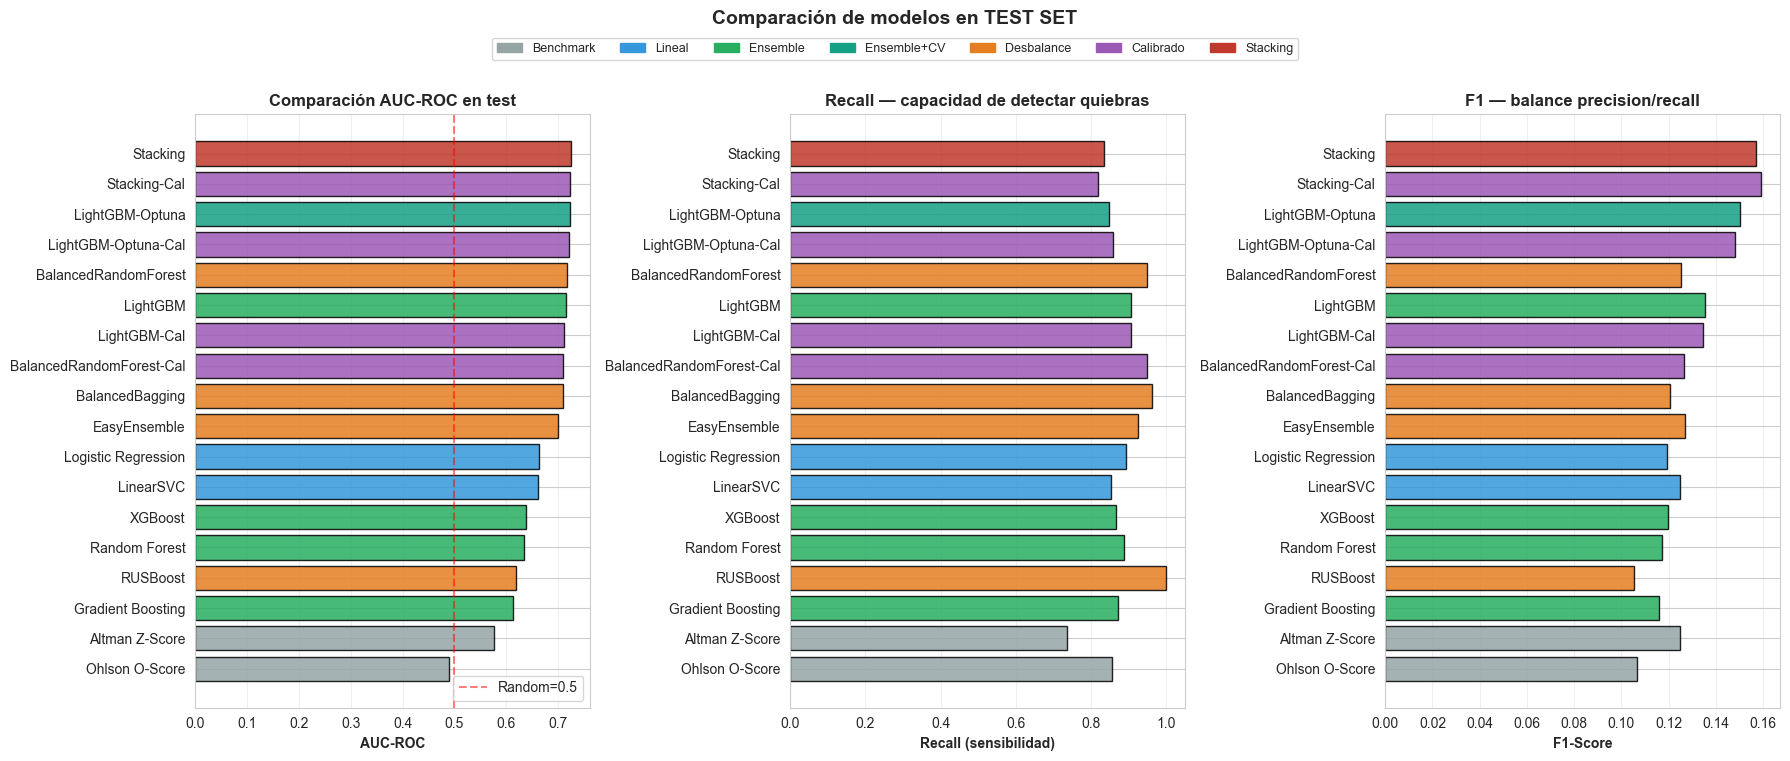

In [13]:
# ── FIGURA 1: Tabla comparativa visual ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, max(6, len(df_master)*0.4)))

df_plot = df_master.sort_values('AUC_ROC')
color_map = {'Benchmark':'#95a5a6','Lineal':'#3498db','Ensemble':'#27ae60',
             'Ensemble+CV':'#16a085','Desbalance':'#e67e22','Calibrado':'#9b59b6','Stacking':'#c0392b'}
colors = [color_map.get(c, '#7f8c8d') for c in df_plot['Categoria']]

axes[0].barh(df_plot['Modelo'], df_plot['AUC_ROC'], color=colors, edgecolor='black', alpha=0.85)
axes[0].set_xlabel('AUC-ROC', fontweight='bold')
axes[0].set_title('Comparación AUC-ROC en test', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].axvline(0.5, color='red', ls='--', alpha=0.5, label='Random=0.5')
axes[0].legend(loc='lower right')

axes[1].barh(df_plot['Modelo'], df_plot['Recall'], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Recall (sensibilidad)', fontweight='bold')
axes[1].set_title('Recall — capacidad de detectar quiebras', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

axes[2].barh(df_plot['Modelo'], df_plot['F1'], color=colors, edgecolor='black', alpha=0.85)
axes[2].set_xlabel('F1-Score', fontweight='bold')
axes[2].set_title('F1 — balance precision/recall', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')

# Leyenda de colores
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=v, label=k) for k,v in color_map.items()]
fig.legend(handles=patches, loc='upper center', ncol=7, bbox_to_anchor=(0.5, 1.02), fontsize=9)
plt.suptitle('Comparación de modelos en TEST SET', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()


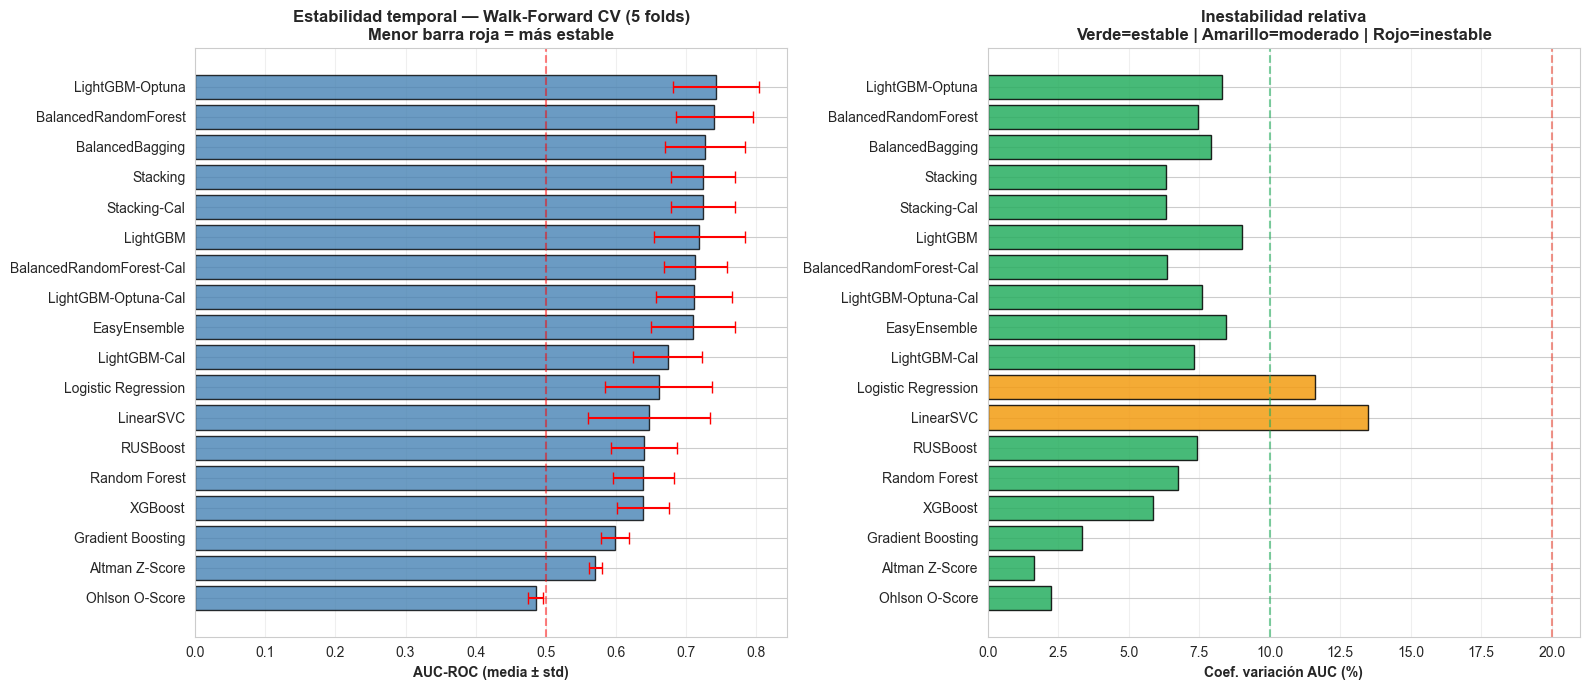

In [14]:
# ── FIGURA 2: CV Walk-Forward — estabilidad temporal ──────────────────
df_cv_plot = pd.DataFrame(all_cv_results).sort_values('CV_AUC_mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# AUC promedio ± std (barras de error)
y_pos = np.arange(len(df_cv_plot))
axes[0].barh(y_pos, df_cv_plot['CV_AUC_mean'],
              xerr=df_cv_plot['CV_AUC_std'],
              color='steelblue', edgecolor='black', alpha=0.8, ecolor='red', capsize=4)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_cv_plot['Modelo'])
axes[0].invert_yaxis()
axes[0].set_xlabel('AUC-ROC (media ± std)', fontweight='bold')
axes[0].set_title('Estabilidad temporal — Walk-Forward CV (5 folds)\nMenor barra roja = más estable', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].axvline(0.5, color='red', ls='--', alpha=0.5)

# Coeficiente de variación
cv_pct = (df_cv_plot['CV_AUC_std'] / df_cv_plot['CV_AUC_mean']) * 100
colors2 = ['#27ae60' if v<=10 else ('#f39c12' if v<=20 else '#e74c3c') for v in cv_pct]
axes[1].barh(y_pos, cv_pct, color=colors2, edgecolor='black', alpha=0.85)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(df_cv_plot['Modelo'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Coef. variación AUC (%)', fontweight='bold')
axes[1].set_title('Inestabilidad relativa\nVerde=estable | Amarillo=moderado | Rojo=inestable', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].axvline(10, color='#27ae60', ls='--', alpha=0.6)
axes[1].axvline(20, color='#e74c3c', ls='--', alpha=0.6)

plt.tight_layout(); plt.show()


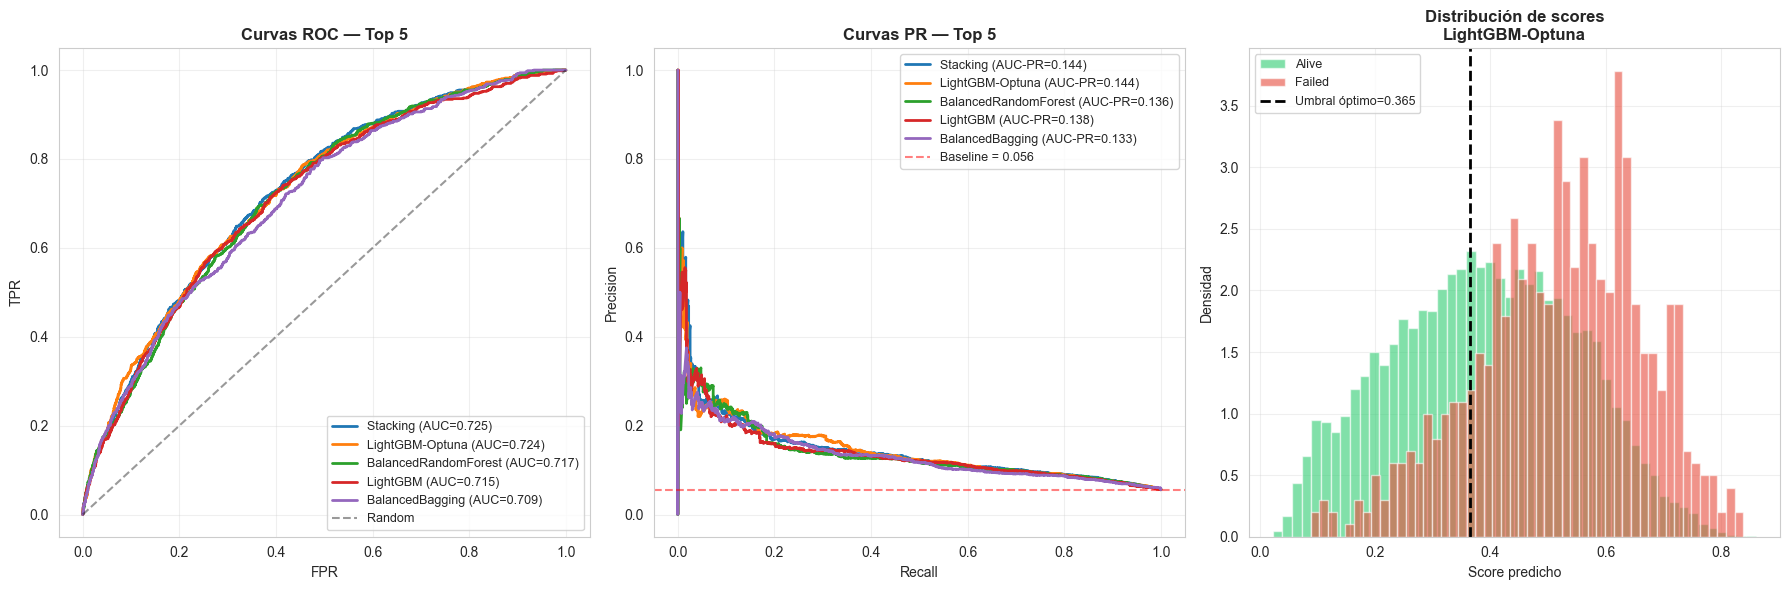

In [15]:
# ── FIGURA 3: Curvas ROC y PR del top-5 ───────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette = plt.cm.tab20(np.linspace(0, 1, 10))

# Top-5 modelos por AUC en test (no calibrados, no benchmarks)
top5 = df_master[~df_master['Categoria'].isin(['Calibrado'])].head(5)

# ROC
for i, (_, row) in enumerate(top5.iterrows()):
    mname = row['Modelo']
    if mname == 'Altman Z-Score':
        pt = p_altman_test.values; yt = y_test_altman.values
    elif mname == 'Ohlson O-Score':
        pt = p_ohlson_test.values; yt = y_test_altman.values
    elif mname == 'Stacking':
        pt = pt_st; yt = y_test.values
    elif mname in model_objects:
        pt = model_objects[mname].predict_proba(X_test_sc)[:,1]; yt = y_test.values
    else:
        continue
    fpr, tpr, _ = roc_curve(yt, pt)
    axes[0].plot(fpr, tpr, color=palette[i], lw=2,
                  label=f'{mname} (AUC={row["AUC_ROC"]:.3f})')

axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC — Top 5', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9); axes[0].grid(True, alpha=0.3)

# PR
for i, (_, row) in enumerate(top5.iterrows()):
    mname = row['Modelo']
    if mname == 'Altman Z-Score':
        pt = p_altman_test.values; yt = y_test_altman.values
    elif mname == 'Ohlson O-Score':
        pt = p_ohlson_test.values; yt = y_test_altman.values
    elif mname == 'Stacking':
        pt = pt_st; yt = y_test.values
    elif mname in model_objects:
        pt = model_objects[mname].predict_proba(X_test_sc)[:,1]; yt = y_test.values
    else:
        continue
    prec, rec, _ = precision_recall_curve(yt, pt)
    axes[1].plot(rec, prec, color=palette[i], lw=2,
                  label=f'{mname} (AUC-PR={row["AUC_PR"]:.3f})')

axes[1].axhline(y_test.mean(), color='red', ls='--', alpha=0.5,
                 label=f'Baseline = {y_test.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas PR — Top 5', fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9); axes[1].grid(True, alpha=0.3)

# Distribución de scores
ax3 = axes[2]
if BEST_MODEL_NAME == 'Stacking':
    p_best = pt_st
elif BEST_MODEL_NAME in model_objects:
    p_best = model_objects[BEST_MODEL_NAME].predict_proba(X_test_sc)[:,1]
else:
    p_best = pt_st
ax3.hist(p_best[y_test==0], bins=50, alpha=0.6, color='#2ecc71',
          density=True, label='Alive')
ax3.hist(p_best[y_test==1], bins=50, alpha=0.6, color='#e74c3c',
          density=True, label='Failed')
ax3.axvline(BEST['Umbral'], color='black', ls='--', lw=2,
             label=f'Umbral óptimo={BEST["Umbral"]:.3f}')
ax3.set_xlabel('Score predicho'); ax3.set_ylabel('Densidad')
ax3.set_title(f'Distribución de scores\n{BEST_MODEL_NAME}', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


---
## PARTE IX: Interpretabilidad SHAP

**Nota importante sobre SHAP en Stacking:** Si el modelo seleccionado como ganador es el ensemble Stacking, los valores SHAP **no se calculan sobre el meta-modelo** (Logistic Regression sobre 4 probabilidades) sino **sobre el modelo base más influyente del ensemble** — aquel cuyas predicciones contribuyen más al meta-modelo según su peso (coeficiente de logit) y/o su AUC individual.

Esta decisión metodológica es necesaria porque:

1. El meta-modelo del Stacking sólo tiene 4 features (las probabilidades de los 4 base models) y SHAP sobre él sería trivial (cuántas probabilidades suben/bajan el score final).
2. Los modelos base son los que conectan las **70+ variables financieras** con la predicción de quiebra, por lo que la interpretabilidad sobre los features económicos relevantes (ROA, Debt_Ratio, etc.) sólo se obtiene del modelo base.
3. Esta práctica es estándar en literatura aplicada de Machine Learning interpretable (Lundberg & Lee, 2017; Molnar, 2020) cuando el modelo final es un ensemble heterogéneo.

En consecuencia, las explicaciones SHAP reportadas corresponden al **modelo base más influyente del Stacking**, no al ensemble completo. Esta limitación se reconoce explícitamente en la discusión de resultados.


=== SHAP — interpretabilidad del modelo seleccionado ===


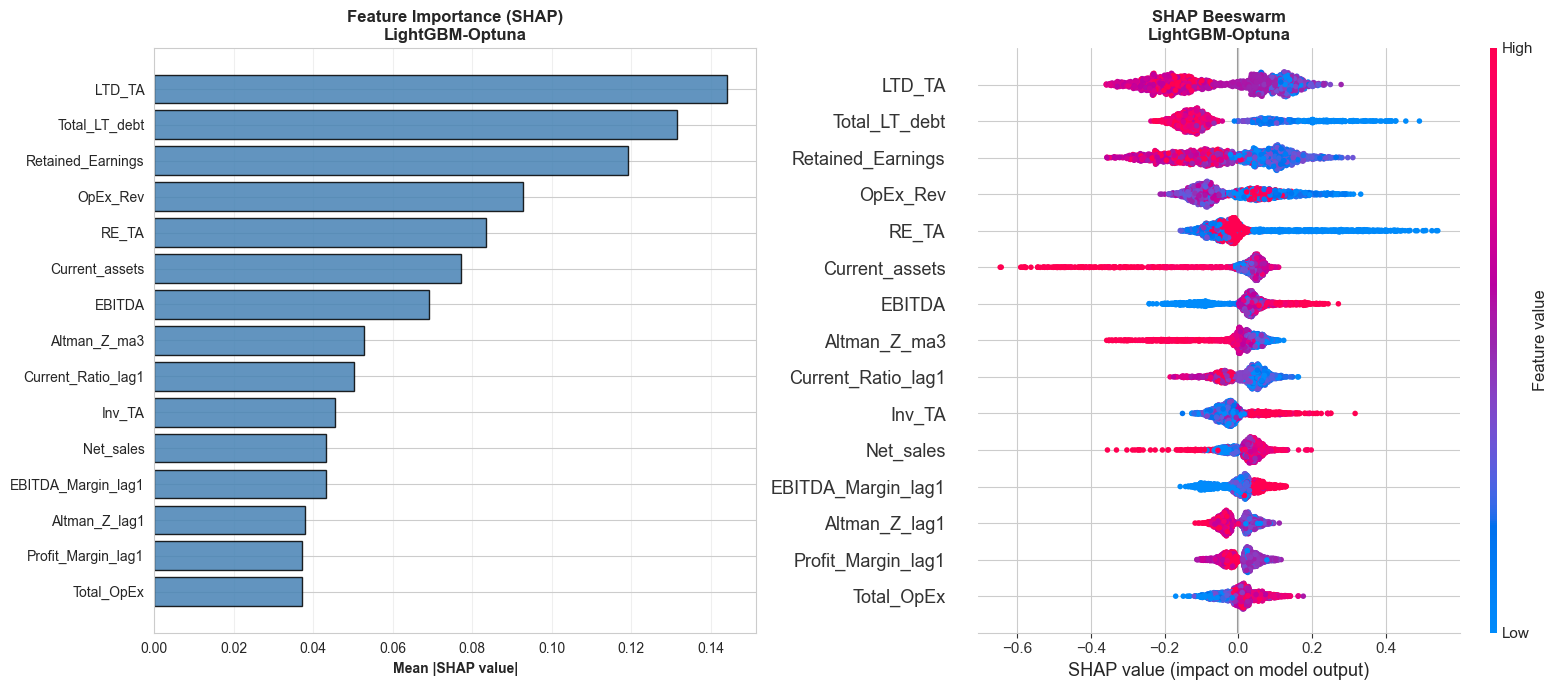


Top 10 variables más importantes (SHAP):
           Feature  SHAP_mean
            LTD_TA   0.144132
     Total_LT_debt   0.131587
 Retained_Earnings   0.119114
          OpEx_Rev   0.092721
             RE_TA   0.083411
    Current_assets   0.077117
            EBITDA   0.068989
      Altman_Z_ma3   0.052822
Current_Ratio_lag1   0.050247
            Inv_TA   0.045441


In [16]:
import shap
print(f'=== SHAP — interpretabilidad del modelo seleccionado ===')

# Selección del modelo a explicar
if BEST_MODEL_NAME == 'Stacking':
    # SHAP no es directamente compatible con el Stacking (su input son probabilidades,
    # no las variables financieras originales). Usamos el modelo base más influyente,
    # según los pesos del meta-modelo. Ver markdown anterior para justificación.
    abs_weights = np.abs(meta.coef_[0])
    most_influential_idx = np.argmax(abs_weights)
    shap_name = stack_names[most_influential_idx]
    shap_obj  = model_objects[shap_name]
    SHAP_NOTE = (
        f'NOTA: El modelo seleccionado es Stacking. SHAP se aplica sobre el modelo base\n'
        f'      más influyente: "{shap_name}" (peso meta-modelo={meta.coef_[0][most_influential_idx]:+.4f}).\n'
        f'      Esta es una APROXIMACIÓN a la interpretabilidad del ensemble completo.'
    )
    print(SHAP_NOTE)
elif BEST_MODEL_NAME.endswith('-Cal'):
    # Modelo calibrado: la calibración es una transformación monótona del modelo base,
    # por lo que la importancia relativa de features no cambia. Usamos el modelo base.
    shap_name = BEST_MODEL_NAME.replace('-Cal','')
    shap_obj  = model_objects[shap_name]
    SHAP_NOTE = (f'NOTA: Modelo seleccionado es calibrado. SHAP se aplica sobre el modelo base\n'
                 f'      "{shap_name}" (la calibración isotónica es monótona y no altera\n'
                 f'      el ordenamiento de feature importances).')
    print(SHAP_NOTE)
else:
    shap_name = BEST_MODEL_NAME
    shap_obj  = model_objects[shap_name]
    SHAP_NOTE = ''

sample_n   = min(2000, len(X_test_sc))
X_shap     = X_test_sc.iloc[:sample_n]

# TreeExplainer para modelos basados en árboles (RF, XGB, LightGBM, GB, etc.)
# LinearExplainer para modelos lineales
try:
    explainer = shap.TreeExplainer(shap_obj)
    shap_values = explainer.shap_values(X_shap)
except Exception:
    # Fallback: Linear o KernelExplainer
    try:
        explainer = shap.LinearExplainer(shap_obj, X_train_sc.sample(500, random_state=42))
        shap_values = explainer.shap_values(X_shap)
    except Exception:
        background = shap.sample(X_train_sc, 100, random_state=42)
        explainer = shap.KernelExplainer(shap_obj.predict_proba, background)
        shap_values = explainer.shap_values(X_shap, nsamples=100)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values
# Algunos shap versions retornan (n, m, 2) -> tomar la clase 1
if sv.ndim == 3:
    sv = sv[:,:,1]

importance_df = pd.DataFrame({
    'Feature': X_shap.columns,
    'SHAP_mean': np.abs(sv).mean(axis=0)
}).sort_values('SHAP_mean', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top15 = importance_df.head(15)
axes[0].barh(top15['Feature'][::-1], top15['SHAP_mean'][::-1],
             color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Mean |SHAP value|', fontweight='bold')
title_extra = f' (sobre {shap_name})' if BEST_MODEL_NAME != shap_name else ''
axes[0].set_title(f'Feature Importance (SHAP)\n{BEST_MODEL_NAME}{title_extra}', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

plt.sca(axes[1])
shap.summary_plot(sv, X_shap, plot_type='dot', max_display=15, show=False, plot_size=None)
axes[1].set_title(f'SHAP Beeswarm\n{BEST_MODEL_NAME}{title_extra}', fontweight='bold')
plt.tight_layout(); plt.show()

print('\nTop 10 variables más importantes (SHAP):')
print(importance_df.head(10).to_string(index=False))
if SHAP_NOTE:
    print(f'\n{SHAP_NOTE}')


---
## PARTE X: Resumen ejecutivo para la tesis


In [17]:
# ── Calcular lift_20 y lift_10 del modelo seleccionado ─────────────────
if BEST_MODEL_NAME == 'Stacking':
    _pt_lift = pt_st
    _yt_lift = y_test
elif BEST_MODEL_NAME in model_objects:
    _pt_lift = model_objects[BEST_MODEL_NAME].predict_proba(X_test_sc)[:,1]
    _yt_lift = y_test
else:
    _pt_lift = pt_st; _yt_lift = y_test

_order      = np.argsort(-_pt_lift)
_y_sorted   = _yt_lift.values[_order]
_cum_found  = np.cumsum(_y_sorted) / _yt_lift.sum()
lift_20     = _cum_found[int(len(_yt_lift)*0.20)]
lift_10     = _cum_found[int(len(_yt_lift)*0.10)]

print('='*75)
print('RESUMEN EJECUTIVO — TRABAJO DE GRADO')
print('='*75)

n_modelos = len(df_master)
alt  = df_master[df_master['Modelo']=='Altman Z-Score'].iloc[0]
ohl  = df_master[df_master['Modelo']=='Ohlson O-Score'].iloc[0]

print(f'''
DATASET (REAL — sin simulación):
  US Companies Bankruptcy Prediction (1999-2018)
  {len(df):,} observaciones | {df.company_name.nunique():,} empresas únicas
  Tasa de quiebra global: {y_all.mean()*100:.2f}%

METODOLOGÍA DE EVALUACIÓN:
  • Split POR EMPRESA estratificado (70/15/15) — sin solapamiento entre conjuntos
  • Walk-Forward CV (5 folds) sobre train+val ordenado temporalmente
  • Winsorización fit-on-train (sin data leakage)
  • Calibración isotónica sobre validation set (no sobre train)
  • Umbral óptimo por costo financiero (FN={COSTO_FN}, FP={COSTO_FP})

MODELOS EVALUADOS: {n_modelos} en total
  Benchmarks clásicos    : Altman Z-Score (1968), Ohlson O-Score (1980)
  Lineales               : Logistic Regression, LinearSVC
  Ensemble estándar      : Random Forest, Gradient Boosting, XGBoost,
                           LightGBM, LightGBM-Optuna
  Especializados balance : EasyEnsemble, BalancedRandomForest, RUSBoost,
                           BalancedBagging
  Calibrados             : Top-3 con Isotonic Regression sobre val_set
  Stacking               : Meta-LR sobre top-4 modelos

BENCHMARKS CLÁSICOS:
  Altman Z-Score : AUC={alt["AUC_ROC"]:.4f} | Recall={alt["Recall"]:.4f} | TP={int(alt["TP"])} FN={int(alt["FN"])}
  Ohlson O-Score : AUC={ohl["AUC_ROC"]:.4f} | Recall={ohl["Recall"]:.4f} | TP={int(ohl["TP"])} FN={int(ohl["FN"])}

MODELO SELECCIONADO: {BEST_MODEL_NAME}
  AUC-ROC  : {BEST["AUC_ROC"]:.4f}  (vs Altman: {BEST["AUC_ROC"]-alt["AUC_ROC"]:+.4f})
  AUC-PR   : {BEST["AUC_PR"]:.4f}
  Recall   : {BEST["Recall"]:.4f}  ({int(BEST["TP"])} de {y_test.sum()} quiebras detectadas)
  Precision: {BEST["Precision"]:.4f}
  F1       : {BEST["F1"]:.4f}
  MCC      : {BEST["MCC"]:.4f}
  Umbral   : {BEST["Umbral"]:.3f}
  CV AUC   : {BEST["CV_AUC_mean"]:.4f} ± {BEST["CV_AUC_std"]:.4f} (estabilidad temporal)
  Lift 20% : Top 20% de empresas por score captura {lift_20:.1%} de todas las quiebras
  Lift 10% : Top 10% captura {lift_10:.1%}
''')

print('TOP 5 MODELOS POR AUC-ROC:')
print(df_master[['Modelo','Categoria','AUC_ROC','AUC_PR','Recall','F1','TP','FN',
                  'CV_AUC_mean','CV_AUC_std']].head(5).to_string(index=False))


RESUMEN EJECUTIVO — TRABAJO DE GRADO

DATASET (REAL — sin simulación):
  US Companies Bankruptcy Prediction (1999-2018)
  78,682 observaciones | 8,971 empresas únicas
  Tasa de quiebra global: 6.63%

METODOLOGÍA DE EVALUACIÓN:
  • Split POR EMPRESA estratificado (70/15/15) — sin solapamiento entre conjuntos
  • Walk-Forward CV (5 folds) sobre train+val ordenado temporalmente
  • Winsorización fit-on-train (sin data leakage)
  • Calibración isotónica sobre validation set (no sobre train)
  • Umbral óptimo por costo financiero (FN=100, FP=5)

MODELOS EVALUADOS: 18 en total
  Benchmarks clásicos    : Altman Z-Score (1968), Ohlson O-Score (1980)
  Lineales               : Logistic Regression, LinearSVC
  Ensemble estándar      : Random Forest, Gradient Boosting, XGBoost,
                           LightGBM, LightGBM-Optuna
  Especializados balance : EasyEnsemble, BalancedRandomForest, RUSBoost,
                           BalancedBagging
  Calibrados             : Top-3 con Isotonic Regress

---
## PARTE XI: Simulación Monte Carlo y Modelo Integrado Riesgo-Valor

### Marco conceptual

El modelo integrado combina dos metodologías financieras:

**Etapa 3 — Valoración estocástica DCF individualizada por empresa**

El valor de cada empresa se calcula con sus propios fundamentales financieros, no con valores aleatorios extraídos de una distribución general (corrección metodológica respecto a versiones previas). La fórmula es:

$$V_i^{DCF} = \sum_{t=1}^{T} \frac{FCFF_{i,t}}{(1 + WACC_i)^t} + \frac{FCFF_{i,T+1} / (WACC_i - g_i)}{(1 + WACC_i)^T}$$

donde para cada empresa $i$:
- $FCFF_{i,0}$ se estima con sus propios fundamentales: $FCFF_i \approx EBIT_i \times (1 - t_c) + D\&A_i - CapEx_i$, con $t_c = 0.21$ (tasa corporativa US) y $CapEx_i \approx D\&A_i$ (supuesto de steady-state, estándar en valoración corporativa).
- $WACC_i$ se simula como $WACC_i \sim \mathcal{N}(0.10, 0.02)$, truncada en $[0.04, 0.25]$.
- $g_i$ se simula como $g_i \sim \mathcal{N}(0.025, 0.015)$, truncada en $[0.001, 0.08]$.
- $T = 5$ años de proyección explícita.

Para cada empresa se ejecutan $N_{sim}$ simulaciones variando $WACC$ y $g$ (los parámetros más inciertos), manteniendo fijo $FCFF_0$ propio. Esto produce una **distribución del valor específica para cada empresa**, no una distribución general aplicada uniformemente.

**Etapa 4 — Integración riesgo-valor**

El valor ajustado por riesgo de cada empresa es:

$$V_i^{ajustado} = (1 - \hat{P}_{i}^{quiebra}) \times \mathbb{E}[V_i^{DCF}]$$

donde $\hat{P}_i^{quiebra}$ es la probabilidad **calibrada** de quiebra estimada por el modelo de Machine Learning para la empresa $i$, y $\mathbb{E}[V_i^{DCF}]$ es el valor esperado del DCF de esa misma empresa según su propia simulación Monte Carlo.

Esta integración individualizada permite que el modelo capture la interacción entre fundamentales financieros (vía DCF) y riesgo de quiebra estimado por ML, asignando descuentos por riesgo específicos a cada empresa según sus características.


════════════════════════════════════════════════════════════════════════
ETAPA 3: VALORACIÓN DCF INDIVIDUALIZADA POR EMPRESA
════════════════════════════════════════════════════════════════════════
  Modelo de P(quiebra)  : LightGBM-Optuna-Cal
  P(quiebra) media test : 0.0722 (7.22%)
  Prevalencia real test : 0.0557 (5.57%)
  P empresas alive      : 0.0699 | P empresas failed: 0.1122
  Separación alive/failed: 1.6× (discriminación calibrada)

FCFF₀ estimado por empresa (12,009 empresas):
  Media     : $       98.74 M
  Mediana   : $        1.02 M
  P25 - P75 : $      0.07 – $     30.81 M
  Min - Max : $        0.00 – $2,051.96 M

Ejecutando Monte Carlo: 12,009 empresas × 500 simulaciones
  Total iteraciones: 6,004,500
  WACC ~ N(10%, 2%) truncada [4%, 25%]
  g    ~ N(2.5%, 1.5%) truncada [0.1%, 8%]
  Horizonte: 5 años + valor terminal Gordon

Resultados Monte Carlo individualizado (12,009 empresas × 500 sims):
  Valor medio del portafolio (media de E[V_i]) : $    1,584.83 M
  Valor med

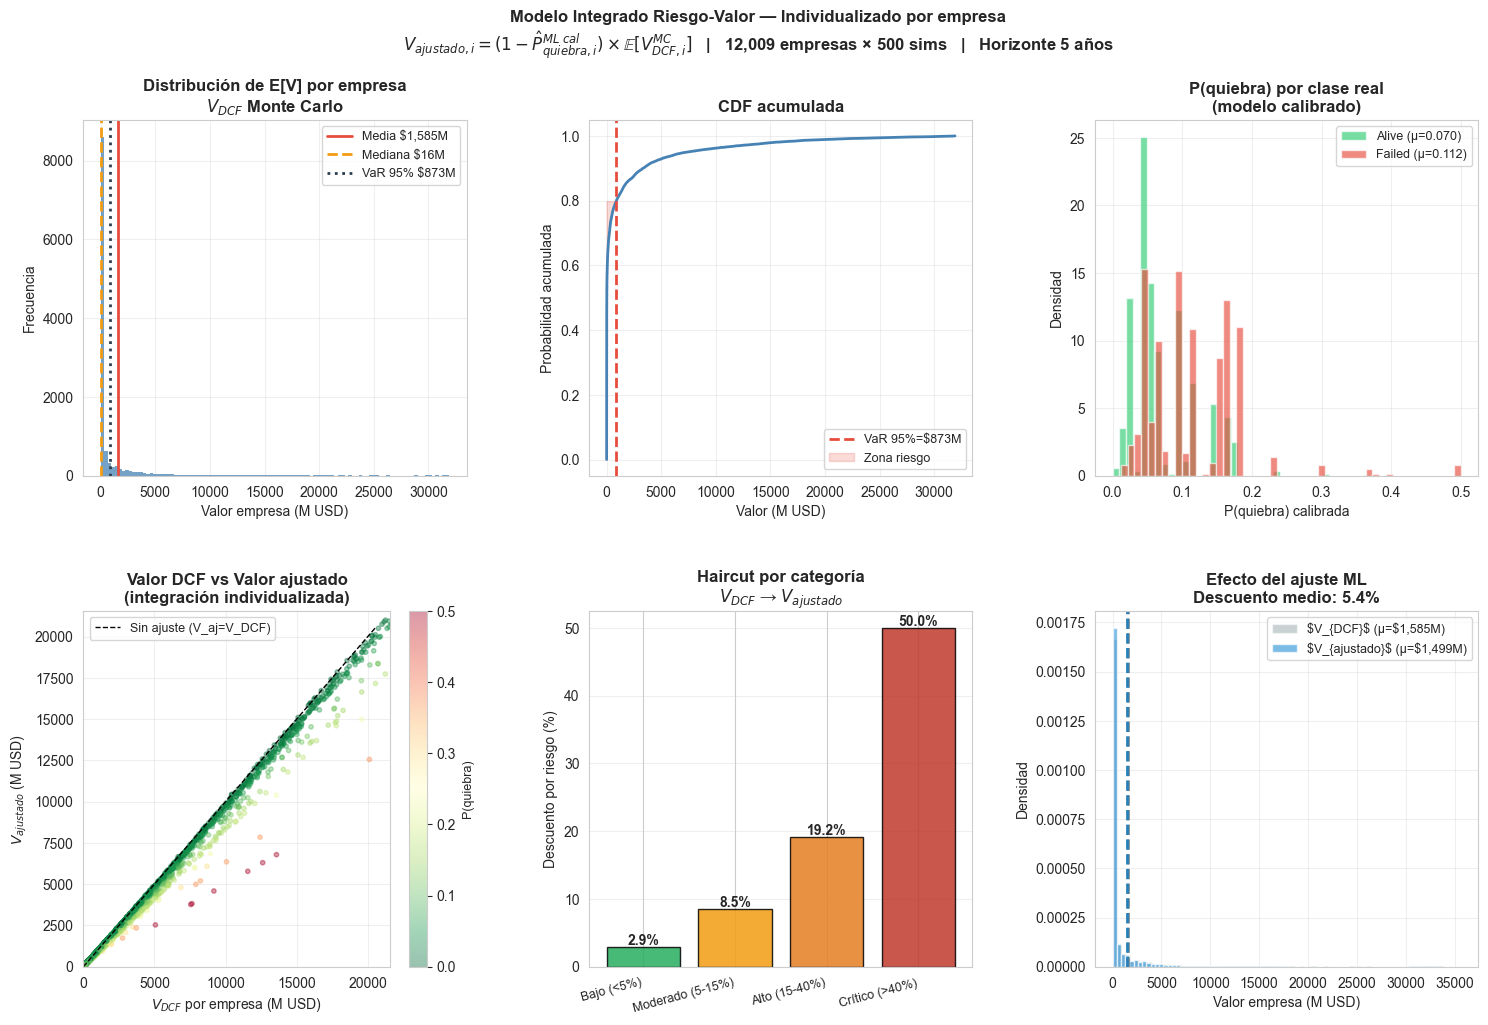


════════════════════════════════════════════════════════════════════════
ANÁLISIS DE SENSIBILIDAD — V_Gordon × (1 - P_quiebra_media)
════════════════════════════════════════════════════════════════════════
FCFF₀ medio=$99M | P(quiebra) media calibrada = 0.0722 (7.22%)

        WACC=7%  WACC=9% WACC=10% WACC=11% WACC=13%
g=1.0%  $1,542M  $1,157M  $1,028M    $925M    $771M
g=2.0%  $1,869M  $1,335M  $1,168M  $1,038M    $849M
g=2.5%  $2,087M  $1,445M  $1,252M  $1,105M    $894M
g=3.0%  $2,359M  $1,573M  $1,348M  $1,179M    $944M
g=4.0%  $3,176M  $1,905M  $1,588M  $1,361M  $1,059M

════════════════════════════════════════════════════════════════════════
RESUMEN — MODELO INTEGRADO INDIVIDUALIZADO
════════════════════════════════════════════════════════════════════════

ETAPA 3 — MONTE CARLO DCF INDIVIDUALIZADO:
  Iteraciones        : 12,009 empresas × 500 sims = 6,004,500
  Horizonte          : 5 años + valor terminal (Gordon Growth Model)
  FCFF₀ por empresa  : EBIT × (1-21%) (steady-state:

In [18]:
# ═══════════════════════════════════════════════════════════════════════
# PARTE XI: SIMULACIÓN MONTE CARLO INDIVIDUALIZADA POR EMPRESA
# Etapa 3: Valoración DCF con fundamentales propios de cada empresa
# Etapa 4: V_ajustado_i = (1 - P_quiebra_calibrada_i) × E[V_DCF_i]
# ═══════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

np.random.seed(RANDOM_STATE)
N_SIM_PER_FIRM = 500   # simulaciones por empresa (variando WACC y g)
T              = 5     # horizonte explícito de proyección
TAX_RATE       = 0.21  # tasa corporativa US (Tax Cuts and Jobs Act 2017+)

# ── Modelo de probabilidades a usar ───────────────────────────────────────
# Usamos el STACKING CALIBRADO: es el modelo con mejor capacidad discriminativa
# (mayor AUC-ROC en clasificación) Y, tras la calibración isotónica sobre el
# conjunto de validación, sus probabilidades reflejan la frecuencia empírica real.
# Esto garantiza coherencia metodológica: el mismo modelo seleccionado como óptimo
# en la predicción de quiebra alimenta la valoración empresarial.
#
# NOTA: los modelos base del Stacking manejan el desbalance (razón 1:14) mediante
# ponderación interna de clases (is_unbalance=True en LightGBM, under-sampling por
# árbol en BalancedRandomForest), NO mediante SMOTE. Esta ponderación infla las
# probabilidades crudas de la clase minoritaria; la calibración isotónica corrige
# ese sesgo, alineando la P(quiebra) media con la prevalencia real del test.
# Modelo calibrado correspondiente al modelo seleccionado por AUC-PR.
# Si el seleccionado es LightGBM-Optuna, usamos su versión calibrada.
MODELO_MC = BEST_MODEL_NAME + '-Cal' if (BEST_MODEL_NAME + '-Cal') in model_objects else 'Stacking-Cal'

p_quiebra_cal = model_objects[MODELO_MC].predict_proba(X_test_sc)[:, 1]

p_media   = float(p_quiebra_cal.mean())
p_failed  = float(p_quiebra_cal[y_test == 1].mean())
p_alive   = float(p_quiebra_cal[y_test == 0].mean())
prev_real = float(y_test.mean())

print('═'*72)
print('ETAPA 3: VALORACIÓN DCF INDIVIDUALIZADA POR EMPRESA')
print('═'*72)
print(f'  Modelo de P(quiebra)  : {MODELO_MC}')
print(f'  P(quiebra) media test : {p_media:.4f} ({p_media:.2%})')
print(f'  Prevalencia real test : {prev_real:.4f} ({prev_real:.2%})')
print(f'  P empresas alive      : {p_alive:.4f} | P empresas failed: {p_failed:.4f}')
print(f'  Separación alive/failed: {p_failed/p_alive:.1f}× (discriminación calibrada)')
print()

# ═══════════════════════════════════════════════════════════════════════
# CÁLCULO DEL FCFF₀ INDIVIDUALIZADO POR EMPRESA
# ═══════════════════════════════════════════════════════════════════════
# FCFF (Free Cash Flow to the Firm) — proxy estándar académico:
#   FCFF = EBIT × (1 - t) + D&A - CapEx - ΔWorking_Capital
# Con supuesto de steady-state: CapEx ≈ D&A y ΔWC ≈ 0
#   → FCFF ≈ EBIT × (1 - t)
# Usamos los datos RAW (no transformados) del test set para preservar magnitudes
# financieras originales en millones de USD.

# Para evitar valoraciones negativas o sin sentido económico:
# - Si EBIT<=0: usamos EBITDA × (1-t) como aproximación conservadora
# - Si EBITDA también es <=0: usamos Net_sales × 0.05 (margen de FCF típico 5%)
# - Si todo falla: usamos un proxy mínimo (1% de Total_assets)

df_mc = df_test_raw.copy().reset_index(drop=True)

ebit       = df_mc['EBIT'].fillna(0).values
ebitda     = df_mc['EBITDA'].fillna(0).values
da         = df_mc['Depreciation_amort'].fillna(0).values
net_sales  = df_mc['Net_sales'].fillna(0).values
tot_assets = df_mc['Total_assets'].fillna(1).values

# FCFF principal: EBIT × (1-t) (steady-state asumido: CapEx=D&A, ΔWC=0)
fcff_main = ebit * (1 - TAX_RATE)

# Fallback 1: EBITDA × (1-t) - D&A (cuando EBIT no es confiable)
fcff_fb1 = ebitda * (1 - TAX_RATE) - da

# Fallback 2: 5% de Net_sales (margen típico de FCF en empresas estables)
fcff_fb2 = net_sales * 0.05

# Fallback 3: 1% de activos (mínimo conservador)
fcff_fb3 = tot_assets * 0.01

# Selección por prioridad (positivo y razonable)
fcff_0 = np.where(fcff_main > 0, fcff_main,
         np.where(fcff_fb1  > 0, fcff_fb1,
         np.where(fcff_fb2  > 0, fcff_fb2, fcff_fb3)))

# Censurar FCFF₀ en percentil 99 para evitar outliers extremos
fcff_0 = np.clip(fcff_0, np.percentile(fcff_0, 1), np.percentile(fcff_0, 99))

# ── CORRECCIÓN DE UNIDADES ────────────────────────────────────────────────
# El dataset (Lombardo et al., 2022) está expresado en MILES de USD.
# Convertimos a MILLONES de USD para reportar en la escala estándar de
# valoración corporativa. Sin esta conversión, las magnitudes quedaban
# infladas 1000x (un FCFF de miles rotulado como millones).
fcff_0 = fcff_0 / 1000.0

print(f'FCFF₀ estimado por empresa ({len(fcff_0):,} empresas):')
print(f'  Media     : ${fcff_0.mean():>12,.2f} M')
print(f'  Mediana   : ${np.median(fcff_0):>12,.2f} M')
print(f'  P25 - P75 : ${np.percentile(fcff_0,25):>10,.2f} – ${np.percentile(fcff_0,75):>10,.2f} M')
print(f'  Min - Max : ${fcff_0.min():>12,.2f} – ${fcff_0.max():,.2f} M')
print()

# ═══════════════════════════════════════════════════════════════════════
# MONTE CARLO POR EMPRESA: simular WACC, g; mantener FCFF₀ propio
# ═══════════════════════════════════════════════════════════════════════
WACC_MEAN, WACC_STD = 0.10, 0.02
G_MEAN,    G_STD    = 0.025, 0.015

n_firms = len(fcff_0)
print(f'Ejecutando Monte Carlo: {n_firms:,} empresas × {N_SIM_PER_FIRM:,} simulaciones')
print(f'  Total iteraciones: {n_firms*N_SIM_PER_FIRM:,}')
print(f'  WACC ~ N({WACC_MEAN:.0%}, {WACC_STD:.0%}) truncada [4%, 25%]')
print(f'  g    ~ N({G_MEAN:.1%}, {G_STD:.1%}) truncada [0.1%, 8%]')
print(f'  Horizonte: {T} años + valor terminal Gordon')
print()

# Vectorizamos: para cada empresa simulamos N_SIM_PER_FIRM trayectorias
# Matriz (n_firms × N_SIM_PER_FIRM)
np.random.seed(RANDOM_STATE)
wacc_sim = np.clip(
    np.random.normal(WACC_MEAN, WACC_STD, (n_firms, N_SIM_PER_FIRM)),
    0.04, 0.25)
g_sim = np.clip(
    np.random.normal(G_MEAN, G_STD, (n_firms, N_SIM_PER_FIRM)),
    0.001, 0.08)
# ── TRUNCAMIENTO CONDICIONAL g < WACC - delta (en CADA iteración) ─────────
# Supuesto declarado: WACC y g se muestrean de forma INDEPENDIENTE. La
# restricción condicional garantiza un denominador de Gordon (WACC - g)
# acotado inferiormente por delta, evitando perpetuidades explosivas cuando
# por azar coinciden un g alto y un WACC bajo. delta = 1.5%.
DELTA_WG = 0.015
g_sim = np.minimum(g_sim, wacc_sim - DELTA_WG)

# FCFF₀ propio de cada empresa, broadcast a cada simulación
fcff_mat = fcff_0[:, None]   # (n_firms, 1)

# Valor presente de los FCFF proyectados (años 1..T)
V_pv = np.zeros((n_firms, N_SIM_PER_FIRM))
for t in range(1, T+1):
    V_pv += fcff_mat * (1 + g_sim)**t / (1 + wacc_sim)**t

# Valor terminal Gordon en t=T
fcff_T1 = fcff_mat * (1 + g_sim)**(T+1)
V_term  = fcff_T1 / (wacc_sim - g_sim) / (1 + wacc_sim)**T

# NOTA: se elimina el cap GLOBAL de V_term (percentil-99 sobre toda la matriz)
# que existía en versiones previas. Ese cap aplicaba el mismo techo a todas
# las empresas y, combinado con miles de firmas pequeñas (FCFF mínimo vía
# fallback), arrastraba el percentil del pool a ~0, produciendo un VaR
# espurio. El truncamiento condicional g<WACC-delta ya acota cada empresa.
V_per_firm = V_pv + V_term   # (n_firms, N_SIM_PER_FIRM)

# ── Estadísticos POR EMPRESA ──────────────────────────────────────────────
V_mean   = V_per_firm.mean(axis=1)
V_median = np.median(V_per_firm, axis=1)
V_std    = V_per_firm.std(axis=1)
V_p05    = np.percentile(V_per_firm, 5, axis=1)   # VaR 95% individual por empresa
V_p01    = np.percentile(V_per_firm, 1, axis=1)   # VaR 99% individual por empresa
V_p95    = np.percentile(V_per_firm, 95, axis=1)
VaR_95_firm = V_p05

# ── VaR del PORTAFOLIO = promedio de los VaR individuales ─────────────────
# (NO el percentil de la distribución agrupada de 6M de valores: ese pool
#  mezcla empresas de escalas dispares y su percentil carece de sentido
#  económico — no existe "la empresa promedio en el percentil 5 del conjunto".)
VaR_95_port = float(V_p05.mean())
VaR_99_port = float(V_p01.mean())
VaR_95_med  = float(np.median(V_p05))

# Distribución agregada solo para histogramas (no para el VaR)
V_sim_flat = V_per_firm.flatten()

print(f'Resultados Monte Carlo individualizado ({n_firms:,} empresas × {N_SIM_PER_FIRM} sims):')
print(f'  Valor medio del portafolio (media de E[V_i]) : ${V_mean.mean():>12,.2f} M')
print(f'  Valor mediano del portafolio                 : ${np.median(V_mean):>12,.2f} M')
print(f'  Desv. estándar entre empresas (de E[V_i])    : ${V_mean.std():>12,.2f} M')
print(f'  VaR 95% (promedio de VaR individuales)       : ${VaR_95_port:>12,.2f} M')
print(f'  VaR 99% (promedio de VaR individuales)       : ${VaR_99_port:>12,.2f} M')
print(f'  Mediana de VaR 95% individual                : ${VaR_95_med:>12,.2f} M')
print(f'  P25 – P75 de E[V_i]  : ${np.percentile(V_mean,25):>10,.2f} – ${np.percentile(V_mean,75):>10,.2f} M')

# ═══════════════════════════════════════════════════════════════════════
# ETAPA 4: INTEGRACIÓN RIESGO-VALOR POR EMPRESA
# ═══════════════════════════════════════════════════════════════════════
print()
print('═'*72)
print('ETAPA 4: MODELO INTEGRADO INDIVIDUALIZADO')
print('V_ajustado_i = (1 - P_quiebra_ML_cal_i) × E[V_DCF_i]')
print('═'*72)

# Cada empresa: su propio E[V_DCF] × (1 - su propia P(quiebra))
V_ajustado_firm = (1 - p_quiebra_cal) * V_mean
descuento_pct   = (1 - V_ajustado_firm.mean() / V_mean.mean()) * 100

df_int = pd.DataFrame({
    'company_name' : df_mc['company_name'].values,
    'fyear'        : df_mc['fyear'].values,
    'FCFF_0'       : fcff_0,
    'P_quiebra'    : p_quiebra_cal,
    'P_solvencia'  : 1 - p_quiebra_cal,
    'V_DCF_mean'   : V_mean,
    'V_DCF_median' : V_median,
    'V_DCF_VaR95'  : VaR_95_firm,
    'V_ajustado'   : V_ajustado_firm,
    'Clase_real'   : y_test.values
})
df_int['Categoria_riesgo'] = pd.cut(
    df_int['P_quiebra'],
    bins=[0, 0.05, 0.15, 0.40, 1.0],
    labels=['Bajo (<5%)', 'Moderado (5-15%)', 'Alto (15-40%)', 'Crítico (>40%)']
)

print(f'  Descuento medio por riesgo: {descuento_pct:.2f}%')
print(f'  V_DCF medio (sin ajuste)  : ${V_mean.mean():>10,.2f} M')
print(f'  V_ajustado medio          : ${V_ajustado_firm.mean():>10,.2f} M')
print()

res_cat = df_int.groupby('Categoria_riesgo', observed=True).agg(
    N               = ('P_quiebra', 'count'),
    P_qbra_media    = ('P_quiebra',  'mean'),
    V_DCF_media     = ('V_DCF_mean', 'mean'),
    V_adj_media     = ('V_ajustado', 'mean'),
    Quiebras_reales = ('Clase_real', 'sum')
).round(2)
res_cat['Descuento_%'] = ((1 - res_cat['V_adj_media'] / res_cat['V_DCF_media']) * 100).round(1)
print('Distribución por categoría de riesgo:')
print(res_cat.to_string())

# ── VISUALIZACIONES ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

# 1. Distribución agregada V_DCF
ax1 = fig.add_subplot(gs[0, 0])
# Histograma de E[V_i] por empresa (no del pool) recortado a p99 para visualización
v_plot = V_mean[V_mean <= np.percentile(V_mean, 99)]
ax1.hist(v_plot, bins=100, color='steelblue', edgecolor='none', alpha=0.75)
ax1.axvline(V_mean.mean(),    color='#e74c3c', lw=2,      label=f'Media ${V_mean.mean():,.0f}M')
ax1.axvline(np.median(V_mean),color='#f39c12', lw=2, ls='--', label=f'Mediana ${np.median(V_mean):,.0f}M')
ax1.axvline(VaR_95_port,        color='#2c3e50', lw=2, ls=':', label=f'VaR 95% ${VaR_95_port:,.0f}M')
ax1.set_xlabel('Valor empresa (M USD)'); ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución de E[V] por empresa\n$V_{DCF}$ Monte Carlo', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# 2. CDF con VaR
ax2 = fig.add_subplot(gs[0, 1])
sv  = np.sort(V_mean[V_mean <= np.percentile(V_mean,99)])
cdf = np.arange(1, len(sv)+1) / len(sv)
ax2.plot(sv, cdf, color='steelblue', lw=2)
ax2.axvline(VaR_95_port, color='#e74c3c', lw=2, ls='--', label=f'VaR 95%=${VaR_95_port:,.0f}M')
ax2.fill_betweenx(cdf[sv<=VaR_95_port], 0, sv[sv<=VaR_95_port], alpha=0.2, color='#e74c3c', label='Zona riesgo')
ax2.set_xlabel('Valor (M USD)'); ax2.set_ylabel('Probabilidad acumulada')
ax2.set_title('CDF acumulada', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# 3. P(quiebra) por clase real
ax3 = fig.add_subplot(gs[0, 2])
for cls, color, lbl in [(0,'#2ecc71','Alive'), (1,'#e74c3c','Failed')]:
    sub = df_int[df_int['Clase_real']==cls]['P_quiebra']
    ax3.hist(sub, bins=50, alpha=0.65, color=color,
             label=f'{lbl} (μ={sub.mean():.3f})', density=True)
ax3.set_xlabel('P(quiebra) calibrada'); ax3.set_ylabel('Densidad')
ax3.set_title('P(quiebra) por clase real\n(modelo calibrado)', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

# 4. V_DCF vs V_ajustado por empresa
ax4 = fig.add_subplot(gs[1, 0])
sc  = ax4.scatter(df_int['V_DCF_mean'], df_int['V_ajustado'],
                  c=df_int['P_quiebra'], cmap='RdYlGn_r', alpha=0.4, s=10)
lim = df_int['V_DCF_mean'].quantile(0.98)
ax4.plot([0, lim],[0, lim], 'k--', lw=1, label='Sin ajuste (V_aj=V_DCF)')
plt.colorbar(sc, ax=ax4).set_label('P(quiebra)', fontsize=9)
ax4.set_xlabel('$V_{DCF}$ por empresa (M USD)'); ax4.set_ylabel('$V_{ajustado}$ (M USD)')
ax4.set_title('Valor DCF vs Valor ajustado\n(integración individualizada)', fontweight='bold')
ax4.set_xlim(0, lim*1.05); ax4.set_ylim(0, lim*1.05)
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)

# 5. Descuento por categoría de riesgo
ax5 = fig.add_subplot(gs[1, 1])
cat_cols = ['#27ae60','#f39c12','#e67e22','#c0392b']
bars = ax5.bar(res_cat.index.astype(str), res_cat['Descuento_%'],
                color=cat_cols, edgecolor='black', alpha=0.85)
for bar, v in zip(bars, res_cat['Descuento_%']):
    ax5.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')
ax5.set_ylabel('Descuento por riesgo (%)')
ax5.set_title('Haircut por categoría\n$V_{DCF}$ → $V_{ajustado}$', fontweight='bold')
ax5.set_xticklabels(res_cat.index, rotation=15, ha='right', fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

# 6. Comparación distribuciones agregadas V_DCF vs V_ajustado
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(df_int['V_DCF_mean'], bins=80, alpha=0.5, color='#95a5a6',
         density=True, label=f'$V_{{DCF}}$ (μ=${df_int["V_DCF_mean"].mean():,.0f}M)')
ax6.hist(df_int['V_ajustado'], bins=80, alpha=0.65, color='#3498db',
         density=True, label=f'$V_{{ajustado}}$ (μ=${df_int["V_ajustado"].mean():,.0f}M)')
ax6.axvline(df_int['V_DCF_mean'].mean(), color='#7f8c8d', lw=2, ls='--')
ax6.axvline(df_int['V_ajustado'].mean(), color='#2980b9', lw=2, ls='--')
ax6.set_xlabel('Valor empresa (M USD)'); ax6.set_ylabel('Densidad')
ax6.set_title(f'Efecto del ajuste ML\nDescuento medio: {descuento_pct:.1f}%', fontweight='bold')
ax6.legend(fontsize=9); ax6.grid(True, alpha=0.3)

fig.suptitle(
    'Modelo Integrado Riesgo-Valor — Individualizado por empresa\n'
    r'$V_{ajustado,i} = (1 - \hat{P}_{quiebra,i}^{ML\ cal}) \times \mathbb{E}[V_{DCF,i}^{MC}]$'
    f'   |   {n_firms:,} empresas × {N_SIM_PER_FIRM:,} sims   |   Horizonte {T} años',
    fontsize=12, fontweight='bold'
)
plt.show()

# ── ANÁLISIS DE SENSIBILIDAD ──────────────────────────────────────────────
print()
print('═'*72)
print('ANÁLISIS DE SENSIBILIDAD — V_Gordon × (1 - P_quiebra_media)')
print('═'*72)
print(f'FCFF₀ medio=${fcff_0.mean():,.0f}M | P(quiebra) media calibrada = {p_media:.4f} ({p_media:.2%})')
print()
wacc_vals = [0.07, 0.09, 0.10, 0.11, 0.13]
g_vals    = [0.01, 0.02, 0.025, 0.03, 0.04]
sens = pd.DataFrame(index=[f'g={g:.1%}' for g in g_vals],
                    columns=[f'WACC={w:.0%}' for w in wacc_vals])
fcff_mean = fcff_0.mean()
for g_v in g_vals:
    for w_v in wacc_vals:
        if w_v > g_v:
            v_gordon = fcff_mean * (1+g_v) / (w_v - g_v)
            v_adj    = v_gordon * (1 - p_media)
            sens.loc[f'g={g_v:.1%}', f'WACC={w_v:.0%}'] = f'${v_adj:,.0f}M'
        else:
            sens.loc[f'g={g_v:.1%}', f'WACC={w_v:.0%}'] = 'N/A'
print(sens.to_string())

# ── RESUMEN FINAL ─────────────────────────────────────────────────────────
print()
print('═'*72)
print('RESUMEN — MODELO INTEGRADO INDIVIDUALIZADO')
print('═'*72)
cat_bajo   = float(res_cat.loc['Bajo (<5%)', 'Descuento_%']) if 'Bajo (<5%)' in res_cat.index else float('nan')
cat_critico = float(res_cat.loc['Crítico (>40%)', 'Descuento_%']) if 'Crítico (>40%)' in res_cat.index else float('nan')

print(f"""
ETAPA 3 — MONTE CARLO DCF INDIVIDUALIZADO:
  Iteraciones        : {n_firms:,} empresas × {N_SIM_PER_FIRM:,} sims = {n_firms*N_SIM_PER_FIRM:,}
  Horizonte          : {T} años + valor terminal (Gordon Growth Model)
  FCFF₀ por empresa  : EBIT × (1-{TAX_RATE:.0%}) (steady-state: CapEx≈D&A, ΔWC≈0)
                       Con fallbacks: EBITDA×(1-t)-D&A; 5%×Net_sales; 1%×Total_assets
  Distribución WACC  : Normal({WACC_MEAN:.0%}, {WACC_STD:.0%}) en [4%, 25%]
  Distribución g     : Normal({G_MEAN:.1%}, {G_STD:.1%}) en [0.1%, 8%]
  Valor medio portafolio: ${V_mean.mean():>10,.2f} M
  Mediana portafolio   : ${np.median(V_mean):>10,.2f} M
  VaR 95% portafolio   : ${VaR_95_port:>10,.2f} M (promedio de VaR individuales)

ETAPA 4 — MODELO INTEGRADO INDIVIDUALIZADO:
  Fórmula   : V_aj_i = (1 - P_quiebra_cal_i) × E[V_DCF_i]
  Modelo ML : {MODELO_MC}
  P media calibrada  : {p_media:.4f} ({p_media:.2%})
  Prevalencia real   : {prev_real:.4f} ({prev_real:.2%})
  V_DCF medio        : ${V_mean.mean():>10,.2f} M
  V_ajustado medio   : ${V_ajustado_firm.mean():>10,.2f} M
  Descuento por riesgo: {descuento_pct:.2f}%

INTERPRETACIÓN:
  • Cada empresa tiene una P(quiebra) propia (del ML calibrado) Y un V_DCF propio
    (calculado con sus fundamentales: EBIT, D&A, ventas). La integración es
    completamente individualizada.
  • Categoría Bajo (<5% riesgo): descuento ~{cat_bajo:.1f}% — empresa financieramente sana
  • Categoría Crítico (>40% riesgo): descuento ~{cat_critico:.0f}% — riesgo extremo
  • Mejora sobre Altman: Altman aplica umbral fijo (Z<1.81=quiebra) sin probabilidad
    continua. Este modelo genera P_quiebra calibrada empresa por empresa y la
    integra con valoración DCF también empresa por empresa.
""")


---
## PARTE XII: Guardado de modelos, resultados y anexos

Esta celda guarda todos los artefactos del análisis para reutilización futura sin necesidad de re-entrenar:

- `models.pkl` — todos los modelos entrenados y calibrados
- `results.pkl` — todas las métricas, datos procesados y resultados intermedios
- `anexo_tabla_maestra.xlsx` — tabla comparativa de modelos (para el jurado)
- `anexo_valoracion_empresas.xlsx` — V_DCF, P_quiebra y V_ajustado por empresa
- `anexo_feature_importance.csv` — importancia SHAP del modelo seleccionado


In [19]:
# ── GUARDAR TODO Y EXPORTAR ANEXOS ────────────────────────────────────────
import joblib, pickle
from pathlib import Path

SAVE_DIR = Path('.')   # carpeta actual

# 1. Modelos entrenados (lo más pesado — tarda horas en re-entrenar)
print('Guardando modelos...', end=' ', flush=True)
joblib.dump(model_objects, SAVE_DIR / 'models.pkl', compress=3)
print(f'OK ({(SAVE_DIR/"models.pkl").stat().st_size/1e6:.1f} MB)')

# 2. Resultados, tablas y objetos del análisis
print('Guardando resultados...', end=' ', flush=True)
resultados = {
    # Datos del pipeline
    'X_train_sc'       : X_train_sc,
    'X_val_sc'         : X_val_sc,
    'X_test_sc'        : X_test_sc,
    'y_train'          : y_train,
    'y_val'            : y_val,
    'y_test'           : y_test,
    'train_companies'  : train_companies,
    'val_companies'    : val_companies,
    'test_companies'   : test_companies,
    # Parámetros de winsorización (fit-on-train)
    'winsor_params'    : winsor_params,
    'train_medians'    : train_medians,
    # Resultados de los modelos
    'all_test_results' : all_test_results,
    'all_cv_results'   : all_cv_results,
    'df_master'        : df_master,
    # Stacking
    'pt_st'            : pt_st,
    'stack_names'      : stack_names,
    'meta_coefs'       : meta.coef_[0],
    # Benchmarks
    'p_altman_test'    : p_altman_test,
    'p_ohlson_test'    : p_ohlson_test,
    # Selección
    'BEST_MODEL_NAME'  : BEST_MODEL_NAME,
    'lift_20'          : lift_20,
    'lift_10'          : lift_10,
    # Monte Carlo individualizado
    'MODELO_MC'        : MODELO_MC,
    'p_quiebra_cal'    : p_quiebra_cal,
    'fcff_0'           : fcff_0,
    'V_per_firm'       : V_per_firm,
    'V_mean'           : V_mean,
    'V_ajustado_firm'  : V_ajustado_firm,
    'df_int'           : df_int,
    'res_cat'          : res_cat,
}
with open(SAVE_DIR / 'results.pkl', 'wb') as f:
    pickle.dump(resultados, f)
print(f'OK ({(SAVE_DIR/"results.pkl").stat().st_size/1e6:.1f} MB)')

# 3. Anexos para el jurado (formatos legibles)
print()
print('Exportando anexos para el jurado...')

# Anexo 1: Tabla maestra de modelos en XLSX
df_master_export = df_master[[
    'Modelo','Categoria','AUC_ROC','AUC_PR','Recall','Precision','F1','MCC',
    'TP','FP','FN','TN','Umbral',
    'CV_AUC_mean','CV_AUC_std','CV_Rec_mean','CV_Rec_std'
]].copy()
df_master_export.to_excel(SAVE_DIR / 'anexo_tabla_maestra.xlsx', index=False, sheet_name='Modelos')
print(f'  • anexo_tabla_maestra.xlsx     → {len(df_master_export)} modelos')

# Anexo 2: Valoración empresa por empresa (test set)
df_int.to_excel(SAVE_DIR / 'anexo_valoracion_empresas.xlsx', index=False, sheet_name='Valoracion')
print(f'  • anexo_valoracion_empresas.xlsx → {len(df_int):,} empresas')

# Anexo 3: Feature importance SHAP
importance_df.to_csv(SAVE_DIR / 'anexo_feature_importance.csv', index=False)
print(f'  • anexo_feature_importance.csv → {len(importance_df)} features')

# Anexo 4: Resumen por categoría de riesgo
res_cat.to_excel(SAVE_DIR / 'anexo_categorias_riesgo.xlsx', sheet_name='Categorias')
print(f'  • anexo_categorias_riesgo.xlsx → {len(res_cat)} categorías')

print()
print('═'*72)
print('PROCESO COMPLETO')
print('═'*72)
print(f'Archivos guardados en {SAVE_DIR.absolute()}:')
print(f'  models.pkl                       → {(SAVE_DIR/"models.pkl").stat().st_size/1e6:.1f} MB')
print(f'  results.pkl                      → {(SAVE_DIR/"results.pkl").stat().st_size/1e6:.1f} MB')
print(f'  anexo_tabla_maestra.xlsx')
print(f'  anexo_valoracion_empresas.xlsx')
print(f'  anexo_feature_importance.csv')
print(f'  anexo_categorias_riesgo.xlsx')
print()
print('Para cargar la próxima vez (saltando re-entrenamiento):')
print("""
import joblib, pickle
model_objects = joblib.load('models.pkl')
d = pickle.load(open('results.pkl', 'rb'))
X_test_sc       = d['X_test_sc']
y_test          = d['y_test']
df_master       = d['df_master']
BEST_MODEL_NAME = d['BEST_MODEL_NAME']
df_int          = d['df_int']
# ... todos los objetos están disponibles en el diccionario d
""")


Guardando modelos... OK (40.1 MB)
Guardando resultados... OK (96.3 MB)

Exportando anexos para el jurado...
  • anexo_tabla_maestra.xlsx     → 18 modelos
  • anexo_valoracion_empresas.xlsx → 12,009 empresas
  • anexo_feature_importance.csv → 70 features
  • anexo_categorias_riesgo.xlsx → 4 categorías

════════════════════════════════════════════════════════════════════════
PROCESO COMPLETO
════════════════════════════════════════════════════════════════════════
Archivos guardados en c:\Users\Hogar\Downloads:
  models.pkl                       → 40.1 MB
  results.pkl                      → 96.3 MB
  anexo_tabla_maestra.xlsx
  anexo_valoracion_empresas.xlsx
  anexo_feature_importance.csv
  anexo_categorias_riesgo.xlsx

Para cargar la próxima vez (saltando re-entrenamiento):

import joblib, pickle
model_objects = joblib.load('models.pkl')
d = pickle.load(open('results.pkl', 'rb'))
X_test_sc       = d['X_test_sc']
y_test          = d['y_test']
df_master       = d['df_master']
BEST_MODEL_NA